# 前言

在人工智能发展的最新浪潮中，大语言模型(Large Language Model，LLM)，以下简称为大模型，已成为通用智能迈向实用化与产业化的关键基石。随着Transformer架构的成熟、算力资源的快速提升以及数据训练范式的不断演进，LLM的应用早已突破传统的问答与对话任务，深入拓展到复杂任务执行、流程控制、工具调用与自主决策等高阶能力的实现之中。

在这一技术背景与需求趋势的交汇点上，智能体系统应运而生。它将LLM的理解与生成能力延展为“感知−认知−执行”一体化的任务执行框架，代表了当前人工智能系统进化的核心方向和未来发展范式。

本书旨在全面系统地讲解如何基于LLM构建智能体系统，聚焦从理论原理到工程实战的全链路技术栈。本书共分13章，涵盖LLM技术基础、Agent核心模块、LangChain框架、LangGraph框架、检索增强生成机制(RAG)、上下文协议(MCP)、多Agent通信（A2A协议）​、扣子低代码平台等关键模块，各章内容概要介绍如下：

第1章从技术演进的视角出发，介绍从专家系统到模型的发展脉络，并剖析智能体系统中的“感知−认知−执行”链条。

第2章详细拆解智能体的核心模块构成与生命周期管理机制，深入解析感知模块、推理规划模块、行动执行模块和记忆系统的协同工作原理。

第3章则聚焦LLM的服务部署与调用方式，详述SaaS与本地模型的部署流程、微调机制、LoRA注入与推理优化策略，为模型落地提供完整技术支持。

第4章介绍LangChain核心组件（LLM接口、Chains、Tools集成、Memory管理）及工具集成、Agent运行机制，涵盖链式逻辑、自定义提示词和动态规划。

第5章聚焦LangGraph编排与任务流管理，探讨其核心概念、与LangChain互补关系、工程化实战案例及与协议层衔接，助力复杂任务处理。

第6章阐述RAG机制原理、文档预处理与向量化，以及基于LangChain的RAG实现，提升智能体检索与生成能力，优化信息处理效率。

第7章系统阐述MCP(Model Context Protocol)协议，提出模型上下文段的结构化表示方法，引入系统提示、工具段、记忆段等组件，实现上下文语义标注、路由控制与动态合并，为多轮对话与任务连续性提供基础支撑。

第8、9章以实践为导向，讲解如何构建具备记忆管理与工具调用能力的单智能体系统，并进一步扩展为支持任务拆分、状态同步、消息调度的多Agent系统。

第10章介绍A2A(Agent-to-Agent)通信协议，定义Agent之间的语义协商语言与消息格式，支持请求−响应、广播−订阅、协商−竞争等多种调度模式，为多智能体系统的信息流转与行为协同提供语义基础。

第11章面向低代码场景，介绍如何利用扣子平台以可视化流程图与自然语言方式快速搭建可用的智能体应用，显著降低Agent系统的开发门槛。

第12、13章结合系统部署、安全加固、性能优化、并发处理与用户交互测试等实际工程问题，展示了一个可部署、可维护、可扩展的智能体系统从“技术原型”走向“产品落地”的完整工程闭环。同时，结合Qwen 3.0与DeepSeek-V1等主流开源模型，深入解析如何进行模型接入、RAG融合、多Agent协作与应用上线，形成一套兼顾工程可行性与产业实战性的开发路径。

本书内容深入浅出、结构严谨、案例翔实，适合希望入门LLM应用开发的初学者、探索Agent开发的工程实践者、构建企业AI平台的技术负责人，也适合作为AI教学或智能体开发团队的技术培训参考书。期待本书能够帮助读者构建一个完整的智能体系统知识体系，掌握大模型落地与Agent应用开发的关键能力，在新时代的AI浪潮中勇立潮头、实现突破。   

                                                                                                 著者
                                                                                                 2025年7月


# 第1章　大模型与智能体技术基础
## 1.1 智能体发展的技术背景
智能体的兴起源于对人工智能从被动响应向主动执行的持续探索，其演化历程伴随着知识系统、规则引擎、深度学习与大模型的阶段性突破。
### 1.1.1 从专家系统到语言模型
专家系统是人工智能早期的重要研究方向，其核心思想是模拟人类专家的知识和推理过程，通过规则库与推理引擎实现对问题的判断、分析与决策，其结构通常包括知识库、推理机、解释器与用户接口等关键组件。

#### 1.专家系统的基本原理
知识库承载了专家所具备的专业知识，通常以如果……那么形式的规则进行编码，规则由知识工程师从实际专家那里收集、整理并维护。

推理机负责在知识库的基础上执行推理操作，常见的方法包括正向链推理与逆向链推理。前者从已知事实出发，逐步推导出结论，后者则从待验证结论出发，回溯推导是否存在支持该结论的规则链。

典型的专家系统的核心模块与信息交互结构如图1-1所示，知识获取模块由知识工程师将领域专家的经验转换为机器可解析的形式，并存入知识库中。形式化的表示通常为规则对或语义网络结构。解释器负责将推理过程中的逻辑路径、结果来源与理由反馈至人机交互界面，提供“why”和“how”的信息，从而增强系统的可解释性与信任度

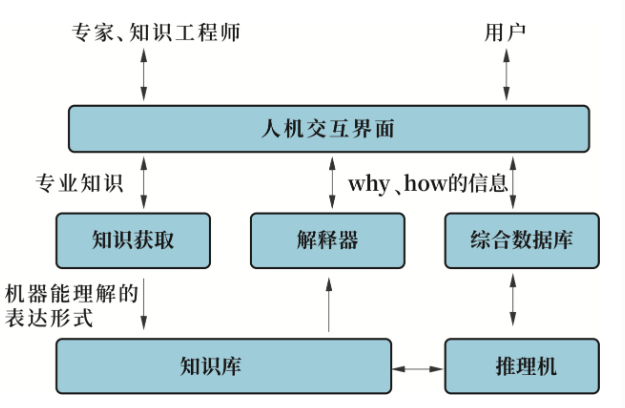

图1-1　专家系统的核心模块与信息交互结构图

综合数据库存储的是运行时数据、事实与用户输入等动态信息。推理机以该数据库为工作记忆，结合知识库中的规则集进行模式匹配、条件验证与推理链构造，从而输出结论或建议。人机交互界面是系统输入与输出的关键桥梁，既接收用户问题，也展示系统推理过程，保障系统的透明性与实用性。

专家系统具备较强的可解释性，输出结论时通常会给出推理路径与依据，适用于结构化明确、规则稳定的封闭领域。然而，其缺点也同样明显，主要包括知识获取困难、规则维护成本高、在面对模糊或开放问题时表现欠佳，缺乏通用性与适应性，尤其在语言理解、视觉感知等复杂任务中难以胜任。

#### 2.统计学习与语言建模的兴起

为解决专家系统的局限，人工智能研究逐步转向数据驱动范式，基于统计学习的方法逐渐取代了符号规则体系。在自然语言处理领域，语言模型成为核心方法之一。最早的语言模型基于n元文法，依赖词频统计构建词序列条件概率分布，尽管可以对短文本进行建模，但在处理长距离依赖与多义歧义问题时效果有限。

随着机器学习的快速发展，神经网络语言模型应运而生。通过引入嵌入向量、隐藏状态与非线性映射函数，模型能够捕捉词语之间的语义关联性。特别是循环神经网络与长短期记忆结构的引入，显著提升了语言模型对上下文的记忆能力，为语言生成、机器翻译、情感分析等任务提供了更强的建模能力。

#### 3.Transformer模型与语言智能体的奠基

标准Transformer编码器结构如图1-2所示，其核心由多头注意力机制与前馈网络组成。输入经过嵌入层后与位置编码相加，形成具备顺序感知能力的表示向量，再通过多头注意力模块进行全局依赖建模。各注意头并行计算不同语义维度下的相关性，结果通过线性投影融合，并与残差连接与层归一化组合形成稳定的特征通路。

接下来，数据经过逐位置独立的前馈网络完成非线性变换，进一步提升表示能力。最终，经过线性变换与归一化后，通过Softmax生成预测概率。整个结构可重复堆叠，形成深层语义建模能力，是现代语言智能体生成能力与推理能力的基础构件。

基于Transformer结构构建的大规模预训练模型，如BERT、GPT、T5等，不仅具备强大的文本生成与理解能力，还表现出一定的推理、归纳与任务迁移能力。随着模型规模从亿级参数扩展至百亿、千亿规模，语言模型已不仅仅是语言处理工具，而逐渐具备了类通用智能的能力，可以通过Prompt（提示词）引导完成摘要、编程、检索、问答、规划等多种任务。

三种基于Transformer架构的变体模型如图1-3所示。标准Transformer包含编码器与解码器两个子模块。编码器利用双向注意力处理输入，解码器通过掩码多头注意力机制防止未来信息泄露，用于序列到序列的建模。GPT采用解码器结构的简化版本，仅保留单向掩码注意力层，支持自回归文本生成，是典型的生成式预训练模型。BERT则完全基于编码器堆叠，通过双向注意力捕捉上下文信息，用于构建深层语义表示，广泛应用于分类、问答与抽取等理解任务。这三种结构定义了预训练语言模型的基本范式，是现代语言智能体系统任务建模与能力构建的理论基础。

这类语言模型逐步承担起语言智能体的角色，能够在开放环境中接收自然语言指令，理解用户意图，并通过语言生成方式完成复杂任务的决策与执行，展现出超越传统专家系统的灵活性与适应性。

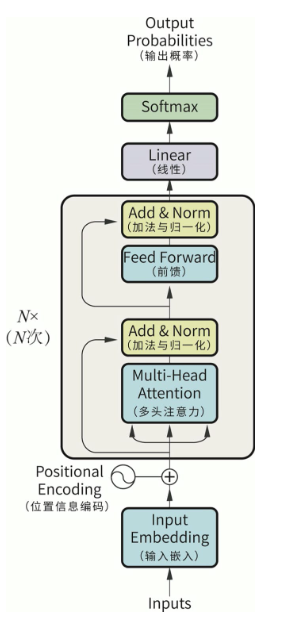

图1-2　Transformer编码器结构及其在语言建模中的计算流程

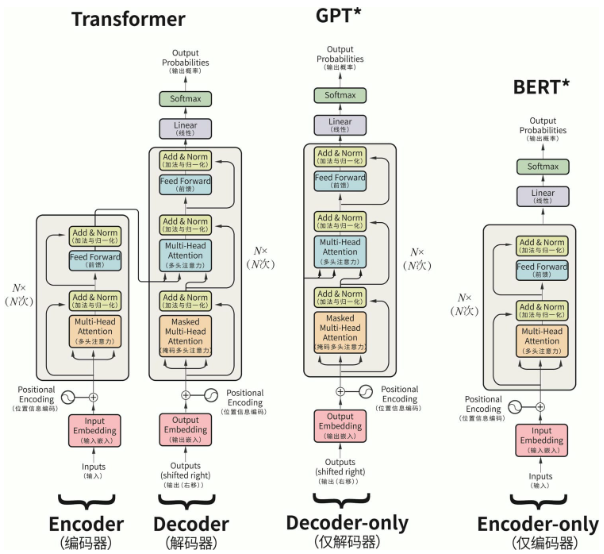

图1-3　Transformer、GPT与BERT结构对比及其模型架构差异

#### 4.范式转移与智能体系统的演化

从专家系统到语言模型的发展过程，实质上是人工智能从符号主义向连接主义，从人工规则向统计学习的根本转变。专家系统强调形式逻辑与可解释性，而现代语言模型则依赖大规模数据与非线性表示，具有更强的泛化能力与任务适应性。

这种范式转移催生了以语言模型为核心的智能体系统。新一代智能体不再依赖预定义的规则集，而是通过上下文建模、Prompt设计、外部工具调用与反馈机制实现任务执行，其结构更加开放，能力更加强大，可适应多领域、多任务的复杂交互场景。

综上所述，从专家系统到语言模型的发展历程，展现了人工智能技术体系的重大跃迁，为构建具备认知、推理与行动能力的智能体系统奠定了理论基础与技术条件，预示着通用人工智能时代的发展方向。

### 1.1.2 感知−认知−执行

感知−认知−执行(Perception-Cognition-Action)模型是构建智能体系统不可或缺的基础结构，在语言智能体架构中，该模型被具体化为语言理解、推理规划与工具调用3个关键能力模块，三者通过上下文结构与任务接口紧密协同，实现智能体从被动应答到主动决策的能力跃升。该机制不仅适用于单一Agent的任务流程，也为多智能体系统中的角色划分与协作设计提供了可扩展的结构模板。

#### 1.感知−认知−执行的基本框架

感知−认知−执行是智能体系统中核心的运行框架，其本质是模拟人类或自然智能体完成信息获取、任务决策与行动反馈的全过程，是支撑智能体自主行为与任务完成的基本逻辑链条，如图1-4所示。在人工智能领域，尤其是在大模型驱动的智能体系统中，这一结构被抽象为多层协同的任务处理体系，每个阶段对应不同类型的计算组件与信息流转机制。

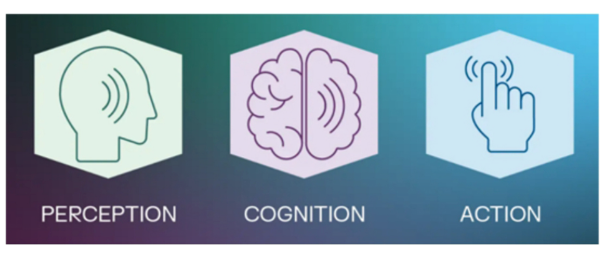

图1-4　感知−认知−执行框架

感知阶段主要负责对外部环境或用户输入进行理解与表征，认知阶段则在理解的基础上进行逻辑推理、任务规划与策略生成，执行阶段根据认知结果完成具体动作，如调用工具、访问数据库或与用户交互。三者之间具有明显的阶段性，但又通过共享上下文与中间状态保持紧密的动态耦合。

#### 2.感知阶段：信息的获取与语言解析

传统系统中，感知通常是指对物理世界的传感器数据进行采集与初步处理，如图像识别、语音转录或温度检测等。而在语言模型驱动的智能体中，感知的主要内容转换为对自然语言输入的理解与语义抽取，即将非结构化的语言表达转换为结构化的意图表示或问题形式。

这一阶段主要包括：
(1)对输入内容的语言解析能力，如句法分析、关键词提取、实体识别。
(2)对用户意图的语义建模能力，如判断请求类型、识别操作对象。
(3)对上下文历史的融合能力，实现多轮对话的上下文连贯理解。

大模型凭借其强大的文本表示能力，能够在这一阶段完成对复杂指令、多语言文本及模糊表达的深度理解，是构建任务驱动型Agent的前提条件。

#### 3.认知阶段：推理规划与行为决策

认知阶段是整个智能体系统的核心部分，涉及信息整合、逻辑推理、策略选择与任务规划等一系列认知计算过程。在这一阶段，智能体不仅要基于当前输入作出判断，还要综合历史信息、任务目标、系统状态以及外部知识进行多层次的分析与抽象。

该阶段可进一步细化为：
(1)意图识别与任务分类：确定请求类型，是查询、生成、控制还是操作。
(2)任务分解与规划：将复杂任务划分为多个子步骤，并确定执行顺序。
(3)工具选择与参数设计：根据任务目标选择合适的工具链并构造输入参数。
(4)回退与错误预判：识别潜在失败路径，构造容错与中断恢复机制。

现代大模型如通义千问Qwen 3.0、GPT-4等具备一定的链式思维与上下文推理能力，在合理设计Prompt与上下文结构的基础上，可以支持有限复杂度的规划与决策操作，是认知阶段能力实现的技术核心。


#### 4.执行阶段：动作调度与工具调用

执行阶段是认知结果的具体实现，承担任务的“最后一公里”落地工作。在传统系统中，执行通常通过调用函数、控制接口或机械部件实现，而在语言智能体中，执行往往表现为工具调用、API接口访问、数据库查询、函数执行等可编程行为。

关键构成包括：
(1)动作调度模块：根据认知输出确定需要调用的工具及其执行顺序。
(2)工具集成接口：将各类工具封装为可调用模块，并规范输入输出格式。
(3)调用反馈管理：处理工具返回结果，包括成功、失败或部分结果处理。
(4)环境状态更新：根据执行结果更新系统状态或用户上下文。

执行阶段不仅需要模型具备语言生成能力，还需依赖工程机制支持外部接口连通，因此通常需要结合LangChain、Function Calling或低代码平台进行落地实现。

#### 5.结构闭环与多轮协同

感知−认知−执行三阶段虽然在逻辑上清晰分离，但在智能体实际运行中常常呈现感知−认知−执行−再感知的闭环结构，即执行结果可能作为新一轮感知输入进入下一轮任务流程。这种循环结构使得智能体具备动态适应与自我修正能力，能够在不确定性环境下持续调整任务策略，提升整体智能表现。

此外，在多轮对话、多步骤任务执行、多Agent协作等场景中，感知−认知−执行链条会跨越多个模块并行展开，此时对上下文状态管理、任务标识追踪与信息流协调提出更高要求，只有构建稳定、统一的上下文传输协议与工具接口标准，才能支撑复杂系统中智能体的协同运行。

### 1.1.3 智能体的系统级结构模型

智能体的系统级结构模型是构建可执行、可扩展、可维护智能系统的基础框架，其核心在于模块化设计、上下文驱动协同与能力层级分布，通过感知、认知、执行、记忆与接口五大模块的有机协作，实现了从自然语言理解到任务完成的完整流程控制。该结构不仅适用于单体Agent的任务系统，也为多智能体协同、异构模型集成与平台级智能系统提供了工程化实施基础。

#### 1.智能体的系统化建模需求

随着大模型的广泛应用与任务复杂度的持续提升，单纯依赖模型调用完成问答或内容生成已难以满足真实场景中的多任务、多步骤、高稳定性需求。语言智能体作为新一代人工智能系统的核心形态，要求在模型能力的基础上构建具备结构化、可控性与模块协同能力的系统框架。因此，构建一套系统级的智能体结构模型，成为智能体工程化部署与多场景落地的前提条件。

系统级智能体模型不仅仅是语言模型的调用封装，更是感知理解、任务规划、行为执行与状态管理等模块的有机协作，是一个面向全流程、多层次的信息处理与响应体系。其构建需要在架构层、组件层与通信层等维度进行系统性设计，确保智能体具备模块独立性、调用通用性与状态可持续性。

#### 2.智能体的核心组成模块

典型的系统级智能体结构通常包括五大核心模块：感知模块、认知模块、执行模块、记忆模块与接口模块，每个模块各司其职，协同工作，构成完整的智能处理链路。

(1)感知模块：负责接收用户输入或外部环境状态，完成自然语言解析、实体识别、意图抽取等任务，是连接输入源与内部认知机制的桥梁。
(2)认知模块：承担主要的信息加工与决策任务，包括问题理解、任务分类、流程规划、工具选择等，是智能体的推理中心。
(3)执行模块：将认知阶段的决策结果转换为具体动作，常表现为工具函数的调用、API接口访问或外部系统控制，是完成实际任务的手脚系统。
(4)记忆模块：存储智能体运行过程中的短期与长期信息，包括用户历史、中间状态、上下文摘要等，是支持多轮交互与状态保持的记忆系统。
(5)接口模块：实现与外部平台、用户界面、数据库及其他智能体的通信桥接，确保系统可嵌入多种运行环境，是智能体感知世界的通道。

一种典型的语言智能体的运行架构如图1-5所示，其核心由Agent模块负责任务解析与行为决策，接收用户输入后，结合系统状态，通过内嵌的感知、推理与执行机制进行处理。Agent可访问数据库查询结构化信息，调用本地文件读取非结构化数据，或接入多模态传感器实现环境感知，通过上下文建模与Prompt编排完成推理规划。

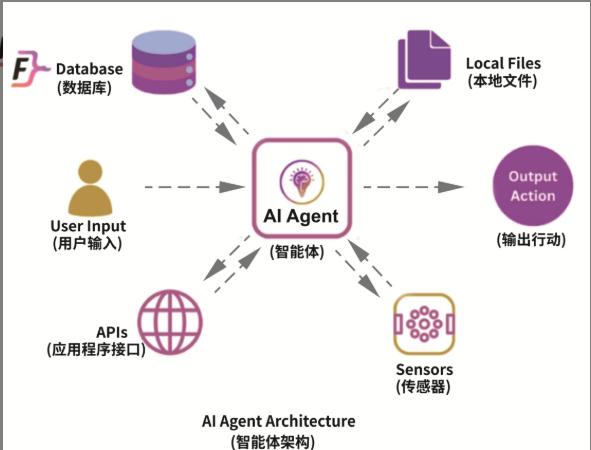

图1-5　AI智能体系统的功能构成与外部接口架构

执行层通过API调用外部服务或控制物理执行器完成任务响应，输出结果可为文本、图像、动作指令等。整个系统支持多通道双向数据流，具备环境适应、自主规划与工具协同能力，是构建复杂任务型AI Agent的基础运行框架。

以上模块通常围绕一个共享的上下文管理系统展开协同，确保信息在模块之间高效流动并被准确调用，是支撑智能体系统稳定运行与可扩展性的基础。

#### 3.模块间的信息流动与协同方式

在系统运行过程中，各模块之间的信息交互基于上下文对象(Context Object)进行统一管理，该上下文结构记录当前任务的输入、用户状态、历史调用记录、中间结果等，是系统级协同的核心信息载体。具体而言：
(1)感知模块将解析后的结构化输入写入上下文。
(2)认知模块从上下文读取用户意图与历史状态，生成行动指令。
(3)执行模块根据指令调用工具，将结果写入上下文。
(4)记忆模块定期将上下文内容进行摘要或分层存储，供后续调用。
(5)接口模块负责上下文与外部环境之间的数据交换与同步。

这种基于上下文驱动的模块协作模式，有利于智能体系统的解耦扩展与过程追踪，也是多智能体系统中信息同步与状态共享的重要支撑机制。

#### 4.智能体系统的分层架构模式

为实现模块功能的清晰划分与系统部署的灵活扩展，智能体系统通常采用分层架构设计，可划分为以下3个层级：

(1)基础模型层：负责底层语言能力的提供，包含大模型的推理服务、Embedding服务、多模态理解模型等。

(2)智能体能力层：以Agent为单位构建任务执行体，包含感知、认知、执行与记忆模块，负责接收任务请求并完成推理与操作流程。

(3)应用与接口层：提供前端交互、系统调用、API封装与多系统协同能力，实现与用户界面或其他平台的集成部署。

这种分层结构使得系统具备良好的模块解耦性与开发可维护性，模型层可以独立升级，能力层支持横向扩展，接口层则可根据场景灵活调整，提高系统的整体稳定性与部署适应性。

#### 5.智能体系统的动态演化机制

现代智能体系统不仅具备静态结构能力，还应具备自适应与演化能力，可在运行中不断学习与优化，主要体现在以下3个方面：

(1)记忆增强与状态沉淀：通过记忆模块对用户行为与交互历史进行建模，实现长期状态的积累与复用。

(2)行为反馈与策略更新：基于任务执行结果自动调整Prompt、工具调用顺序或调用条件，形成自我优化闭环。

(3)模块热插拔与功能迁移：支持动态替换、加载或禁用某些功能模块，使系统具备弹性与可配置能力。

这些演化机制使得智能体不再是静态流程的简单执行器，而逐步演化为具备适应能力的自主系统，具备跨任务、跨场景的泛化应用潜力。

## 1.2 大模型的基本架构

大模型作为智能体系统的认知核心，其架构设计直接决定了语言理解与生成的能力边界。Transformer作为当前主流的大模型基础结构，凭借其自注意力机制与多层堆叠架构，在长距离依赖建模与并行计算效率上取得突破性进展。本节将系统介绍大模型的核心构成与关键机制，重点剖析Transformer的结构原理、编码和解码过程、注意力机制的计算方式以及位置编码的语义作用，为后续智能体系统中的模型能力调度与上下文管理打下结构性认知基础。


### 1.2.1 Transformer结构剖析

Transformer结构作为现代大模型的基础架构，通过自注意力机制、多头注意力、前馈网络、残差连接与位置编码等模块，构建了具备强大上下文建模能力与并行计算优势的神经网络结构。其灵活的编码器−解码器设计不仅适用于语言理解任务，也广泛应用于语言生成、对话系统、多模态交互等场景，是语言智能体系统实现的基础支撑。理解Transformer的结构逻辑是把握大模型行为与智能体能力边界的关键前提。

#### 1.Transformer模型的提出背景

Transformer结构是当前大模型的核心架构，自2017年被提出以来，已成为自然语言处理领域最重要的基础技术之一。其设计初衷是为了解决传统循环神经网络在序列建模中存在的长期依赖问题与训练效率瓶颈。相比于RNN与LSTM，Transformer完全抛弃了时间步迭代结构，采用全并行的自注意力机制，使得模型在序列建模中兼顾了建模能力与计算效率，成为后续BERT、GPT、T5等主流模型的基础结构。

Transformer的核心在于其堆叠式的编码器−解码器架构与全局注意力机制，能够实现对输入序列中任意位置信息的建模，是支持语言理解与生成任务的关键机制，其架构的模块化、层级化特点也极大地增强了系统的可扩展性，便于与其他智能体组件协同构建复杂任务流程。

#### 2.模型整体结构组成

标准的Transformer架构由编码器(Encoder)与解码器(Decoder)两部分构成，分别用于处理输入信息与生成输出结果，整个模型结构呈现对称堆叠的层级设计，每一层均由多个子模块组成，具有高度可复用性与并行计算能力。

(1)编码器部分主要负责接收输入序列，通过多层自注意力机制与前馈网络提取上下文表示，输出每个位置对应的上下文特征。

(2)解码器部分则以编码器输出为条件，通过掩码自注意力与交叉注意力机制生成目标序列，是支持序列生成与翻译等任务的关键。

Transformer模型中的自注意力机制的核心计算过程如图1-6所示。输入序列首先通过嵌入层转换为固定维度向量，再映射为查询、键和值3组向量，经由线性变换生成Q、K、V矩阵。注意力权重由查询向量与键向量的点积计算得到，经缩放后与掩码矩阵相加，用以屏蔽无效位置，再输入Softmax函数生成归一化的注意力分布。

该分布用于加权求和值向量V，输出聚合后的上下文表示。整个过程实现了模型对不同位置信息的动态关注，具备全局依赖建模能力，是Transformer得以捕捉长程依赖并生成语义一致输出的核心算子，广泛应用于语言建模、问答系统与智能体行为控制中。

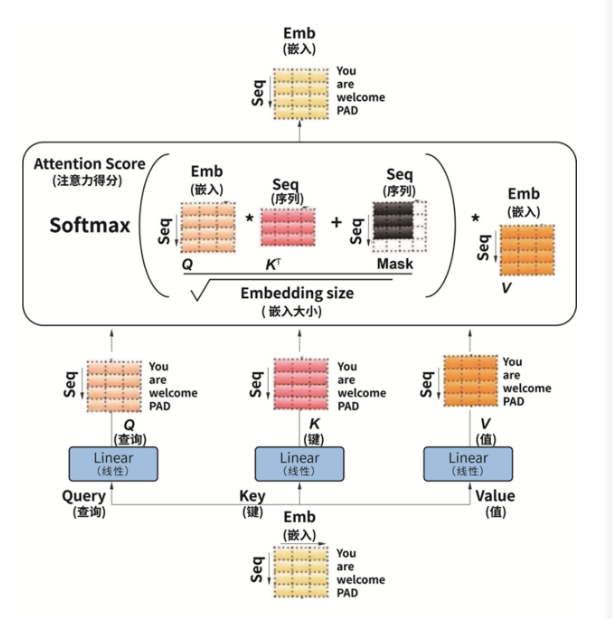

图1-6　Transformer模型中的注意力机制的计算流程图

在实际的大模型中，如GPT系列，通常仅保留解码器结构用于单向生成，而BERT则仅使用编码器结构进行双向理解，结构选择取决于具体任务需求

#### 3.自注意力机制的作用与计算逻辑

Transformer架构的核心机制是自注意力(Self-Attention)，该机制允许模型在处理某个位置的词时，充分考虑序列中其他所有位置的词语信息，从而建立全局的上下文关联关系。这一特性在语言建模中尤为重要，有助于捕捉长距离依赖与语义一致性。

自注意力机制的计算流程本质上是一个加权平均过程，对于输入序列中的每个词向量，计算其与其他词向量之间的相似度，然后根据相似度分配注意力权重，对所有词向量进行加权求和，最终得到该位置的上下文表示。通过这种方式，模型在每一层都能动态重构序列的语义表示，以适应不同任务对上下文理解的需求。

此外，Transformer中的注意力机制通常采用多头注意力(Multi-Head Attention)结构，将注意力计算拆分为多个子空间并行进行，使模型能够从不同角度捕捉语义关系，提升表达能力。

#### 4.前馈网络与残差连接

在每一个Transformer层中，除了自注意力子模块外，还包括一个前馈神经网络(Feed-Forward Network)。该网络作用于每个位置上的表示向量，进一步提升模型的非线性表达能力，通常由两层全连接结构组成，配以激活函数与Dropout（随机失活）操作。

为了加速训练收敛并稳定深层网络的表示能力，Transformer在每个子模块的输入输出之间引入残差连接(Residual Connection)与层归一化(Layer Normalization)，确保在多层堆叠结构下，信息能够顺利传递，避免梯度消失或爆炸问题。这一设计显著提升了模型的深层建模能力与训练稳定性，是Transformer成功的关键工程细节。

#### 5.位置编码机制与顺序建模

由于Transformer不具备序列结构的递归特性，模型本身无法捕捉输入序列中各词的位置信息，因此需显式引入位置编码(Positional Encoding)机制，向输入的词向量中加入位置信息，以便模型感知顺序关系。

常见的实现方式包括固定位置编码与可学习位置编码两种。固定位置编码通过正弦与余弦函数构造各位置的向量表示，具有良好的周期性与可泛化能力；可学习位置编码则将位置向量作为参数在训练过程中学习，灵活性更强。无论采用何种方式，位置编码的本质目的都是在无序输入中注入位置信息，使模型能处理文本中的语序逻辑。

#### 6.堆叠结构与深层表达

Transformer通过将上述模块按顺序堆叠构建多层网络，每一层都会在原始表示上进一步提取更深层次的语义特征，随着层数加深，模型可以逐渐捕捉从词汇层、句法层到语义层的多层次信息，支持复杂语言任务的建模需求。

典型的Transformer序列到序列架构如图1-7所示，其左侧编码器堆叠多层模块，每层包含多头注意力与前馈网络，逐层抽取输入句子的语义特征并构建深层表达。每个词嵌入后通过残差连接与层归一化机制在各层间传递，使模型能够捕捉多粒度、多层次的语言表示。

右侧解码器在每一步生成过程中，结合先前已生成的输出与来自编码器的全局上下文信息，通过掩码机制保证自回归生成特性。整套结构支持源语言到目标语言的高质量转换，是机器翻译、摘要生成等语言智能体任务的基础算子设计。

深层堆叠结构的设计，使得Transformer在面对多语言翻译、文本生成、长文理解等任务时具备极强的表达能力与泛化能力，同时也为后续构建大型预训练模型提供了灵活的参数扩展空间。

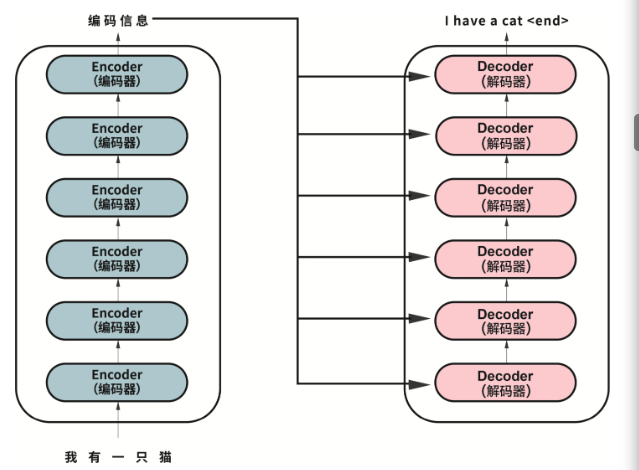

图1-7　基于Transformer的编码−解码翻译结构图


### 1.2.2 编码器与解码器机制

编码器与解码器机制是构建语言理解与生成系统的核心结构，在Transformer架构中实现了结构清晰、效率优越的信息处理链条。编码器侧重于全局语义建模，解码器则侧重于条件文本生成，两者通过注意力机制高效协同，为大模型驱动的智能体系统提供了稳定、可扩展的架构基础。在智能体任务中，编码器−解码器结构不仅支撑语言理解与输出，也构成工具调用、任务规划与多模态协同的底层技术核心。

#### 1.编码器−解码器架构的理论基础

编码器与解码器机制是序列到序列学习(Sequence-to-Sequence，Seq2Seq)模型的核心结构，最早应用于神经机器翻译任务，用于将输入序列映射为语义表示，再生成与其相应的输出序列。在Transformer中，这一机制被进一步拓展为多层堆叠、全注意力结构，显著提升了建模能力与训练效率。编码器负责对输入序列进行全局语义建模，提取信息密集的上下文表示；解码器则利用这些表示生成目标输出序列，是语言理解与生成系统的基础框架。

在现代大模型中，虽然部分模型仅保留其中一个模块（如BERT只使用编码器、GPT只保留解码器）​，但完整的编码器−解码器结构仍是构建具有通用语言理解与生成能力系统的理论源点，其模块划分清晰、功能协同紧密，成为多任务建模与智能体系统构建的重要结构依据。

#### 2.编码器结构与处理流程

编码器的主要任务是接收输入文本序列，将其转换为具有语义表示能力的上下文向量序列，其内部由多个相同结构的编码层堆叠而成，每一层都包含两个子模块：多头自注意力机制与前馈神经网络。

在处理过程中，输入的每个词首先被映射为固定维度的词向量，并添加位置编码用于表征词在序列中的位置信息。随后，自注意力机制计算每个词与序列中其他词的相对关系，从而得到每个位置的上下文加权表示。该机制使模型能够捕捉长距离依赖与全局结构，有效解决传统RNN存在的记忆瓶颈问题。前馈神经网络则负责在每个位置上进行非线性变换，进一步提升语义抽象能力。

在层与层之间，使用残差连接与层归一化以保持信息流动与梯度稳定。最终，编码器输出的每个位置的表示不仅包含该词本身的信息，还融合了与其他位置的语义关联，形成了具备全局上下文感知能力的表示序列，可供后续解码阶段引用。

#### 3.解码器结构与生成机制

解码器的核心任务是基于编码器输出的上下文表示与已生成的目标序列，逐步预测并生成后续词语，其结构同样由多层堆叠组成，但每层包括3个子模块：掩码自注意力机制、编码器−解码器注意力机制与前馈神经网络。

掩码自注意力机制负责处理目标序列的已有部分，为了防止模型在训练阶段窥视未来的输出信息，采用下三角掩码矩阵控制注意力计算，使得每个位置只能关注当前及之前的词语，这种机制确保了解码过程的自回归特性。第二个模块，即编码器−解码器注意力机制，则用于引入编码器的上下文信息，使解码器能够结合输入语义进行输出预测，是实现条件生成与语言对齐的关键模块。第三部分的前馈神经网络与编码器中相同，用于增强表示能力。

在具体生成时，解码器通常采用自回归方式，从起始标记开始，逐步生成一个词，更新输入序列后再生成下一个词，直到生成终止标记或达到最大长度。该机制可用于机器翻译、文本摘要、问答生成等任务，支持条件下的序列建模。

#### 4.编码器与解码器之间的交互关系

编码器与解码器之间通过上下文向量传递机制进行信息交互，编码器输出的每个位置表示被作为解码器注意力机制中的键与值，解码器在生成每个目标词时，根据当前生成状态计算对输入序列中各位置的注意力权重，动态聚合编码器输出，从而实现源语言与目标语言之间的语义映射。

这一设计使得模型能够灵活地对输入信息进行选择性关注，实现更精准的翻译、摘要与内容重构。同时，编码器输出可并行处理整个输入序列，而解码器在训练时可通过并行解码优化效率，在推理时保持逐词生成，兼顾性能与控制能力。

#### 5.模型结构的变体与演化

虽然原始Transformer包含完整的编码器与解码器结构，但在后续应用中，依据任务需求，模型结构也出现了多种变体：

(1)编码器结构独立使用：如BERT模型专注于文本理解，仅使用双向编码器进行上下文建模，适合用于分类、问答、信息抽取等任务。

(2)解码器结构独立使用：如GPT模型采用单向解码器结构进行文本生成，自回归机制确保语言连贯性，是当前主流的大模型架构。

(3)Encoder-Decoder结构融合使用：如T5模型结合两者的优势，适用于翻译、摘要与统一文本任务建模。

此外，近年来的多模态大模型也在编码器与解码器中引入图像、语音、视频等跨模态输入，形成更加复杂的信息交互结构，进一步拓展了语言模型的应用边界。

### 1.2.3 注意力机制与多头注意力

注意力机制是现代语言模型中最具代表性的建模技术，其通过动态分配注意力权重，实现了对信息关系的全局建模与局部聚焦，尤其在Transformer中发展为多头注意力机制，显著增强了模型的表达能力与任务适应性。该机制不仅提升了语言理解与生成的效果，也为智能体系统中复杂任务的感知、认知与协作提供了理论支撑与工程基础，是构建通用智能体能力体系的关键组件。

#### 1.注意力机制的提出背景

在自然语言处理与序列建模任务中，不同词语之间往往存在复杂的依赖关系，尤其是长距离依赖，传统的循环神经网络结构在处理这类关系时常面临信息遗忘与梯度消失等问题。为解决这一瓶颈，注意力机制应运而生，其核心思想是模拟人类在阅读或处理信息时的聚焦行为，即在众多信息片段中分配不同的关注度，重点关注与当前任务相关的信息部分，从而提升整体表达能力。

最初的注意力机制应用于神经机器翻译，在源语言与目标语言之间建立对齐关系，随后被广泛应用于图像处理、语音识别、文本生成等任务，尤其在Transformer结构中成为信息交互的核心机制，取代了传统的递归结构，构建了完全基于注意力的信息处理架构。

#### 2.注意力机制的核心思想

注意力机制通过为输入序列中的每个元素计算其与其他元素之间的相关性或重要程度，从而动态地为每个位置生成加权表示。这一过程包含3个关键要素：查询、键和值。查询表示当前处理的目标位置，键表示所有可被关注的参考位置，值则为每个位置的原始信息表示。最终的输出是所有值向量的加权和，权重由查询与键之间的相关性函数决定。

这种机制的优势在于，可以捕捉序列中任意两个位置之间的相互关系，而无须依赖固定顺序的信息传递路径，极大地增强了模型的建模灵活性与效率，同时也为上下文建模提供了更加精细的控制手段，适应多种语言现象，如主谓一致、同义替换与语义指代等。

#### 3.自注意力机制与序列建模

自注意力机制是注意力机制的一种特化形式，其查询、键和值均来自同一输入序列，允许模型在每一层中捕捉序列内各位置之间的相互依赖关系。在自注意力机制中，每个位置的表示不仅包含自身的信息，也融合了与其他位置之间的语义关联，形成一种全局感知的动态表示方式。

在Transformer中，自注意力机制被广泛应用于编码器与解码器模块的各个层级，通过并行计算与向量化操作实现高效的上下文建模，尤其在处理长文本、复杂语义结构与多轮对话等任务中展现出强大的能力。

#### 4.多头注意力机制的结构设计

尽管单一的注意力机制已经具备一定的建模能力，但在实际任务中，不同的语义关系可能需要在不同的子空间中进行建模。为此，Transformer引入了多头注意力机制，将注意力计算过程拆分为多个头，每个头在不同的低维空间中独立学习注意力分布。

缩放点积注意力机制和多头注意力结构如图1-8所示，通过将查询向量与键向量计算点积后进行缩放，再经Softmax归一化得到注意力分布，用以加权值向量，从而实现对不同位置信息的动态聚焦。该结构有效解决了输入长度变长时点积结果过大导致梯度不稳定的问题，是Transformer中注意力计算的核心算子。

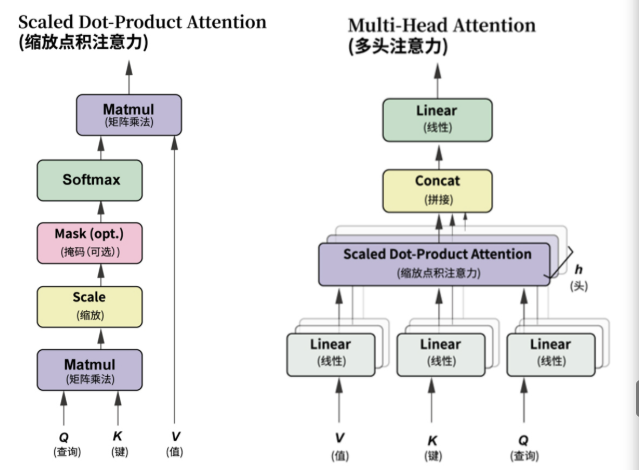

图1-8　多头注意力机制与缩放点积注意力结构图

右侧为多头注意力结构，通过将输入的查询、键、值分别映射为多个子空间，独立执行多组注意力计算，最后将所有注意头的结果拼接并映射回统一空间，从而捕捉不同子空间下的特征表示，增强模型对上下文中多语义维度的理解能力，是实现深层语言建模与多粒度信息融合的关键机制。

具体而言，输入向量被投影为多个子空间，在每个头中分别执行独立的注意力计算过程，然后将各头的输出进行拼接并投影回原始空间，这一机制相当于让模型从多个视角同时建模语义关系，从而提升表达的多样性与细粒度特征感知能力。

多头注意力机制的优势在于：

(1)能够捕捉多类型的语义依赖，如词法关系、句法结构与上下文检索。

(2)提高模型的容量与表达灵活性，避免单一注意力通道的信息瓶颈。

(3)支持大规模参数扩展，有利于预训练模型的性能提升。

在实践中，多头数的设定通常依据模型参数规模、计算资源与任务复杂度进行权衡，是大模型性能调优的重要超参数之一。

#### 5.注意力机制在智能体系统中的作用

在智能体系统中，注意力机制不仅是模型构建的底层基础，也直接影响智能体对信息的感知范围与响应质量。通过注意力机制，模型能够对输入内容中的关键信息进行有效聚焦，从而实现对用户指令的准确理解与任务目标的合理推理，避免信息遗漏或误解。

在复杂任务如多轮对话、任务分解、模态融合等场景中，注意力机制还可用于构建跨步骤、跨模态的信息桥梁，支持Agent在感知与认知过程中对信息进行动态加权与聚焦选择，为智能体系统提供了高度灵活的认知框架与执行依据。

此外，在多Agent协作任务中，注意力机制还可用于构建信息交互策略，如跨Agent注意力对齐、多Agent记忆共享与角色分工引导等，提升系统级协同能力。

### 1.2.4 位置编码与上下文建模

位置编码机制解决了Transformer在处理序列任务时对顺序缺失的问题，是构建大模型上下文建模能力的基础手段。通过结合绝对位置、相对位置与高级扩展策略，位置编码不断演化以适应更长、更复杂的文本建模需求。在语言智能体系统中，位置编码不仅服务于语言模型本身，也深度嵌入对话流程、任务调度与多模块协同中，是构建高质量智能行为链条的核心机制之一。

#### 1.Transformer结构中的位置问题

Transformer模型虽然在注意力机制与并行计算方面带来了巨大优势，但由于其结构不再具备递归或卷积特性，因此在原始设计中完全丧失了对序列中位置信息的感知能力。与传统循环神经网络通过时间步传递维持顺序不同，Transformer对输入的词向量是无序处理的，若无额外机制辅助，模型将无法判断词语在句子中的前后关系，严重影响语言建模能力与语义理解效果。

为解决这一问题，Transformer引入了位置编码(Positional Encoding)机制，通过在词向量中融合位置信息，使模型能够识别序列中各个词的顺序结构，并在注意力计算中综合考虑位置与语义的双重依赖，是构建上下文感知能力的关键基础。

#### 2.位置编码的基本原理

位置编码的核心目标是为输入序列中的每个词分配一个对应的位置向量，再将该向量与原始词向量相加或拼接，从而形成既包含词义信息又包含位置信息的综合表示，使得注意力机制能够在建模词语之间的关系时考虑其在序列中的相对位置或绝对位置。

常见的位置编码方式主要包括两类：固定位置编码与可学习位置编码。固定位置编码通常采用正弦和余弦函数，以不同频率为每个位置生成具有周期性与层级差异的编码向量，该方法具有良好的可解释性与序列泛化能力；而可学习位置编码则将每个位置的编码向量作为模型参数，在训练过程中与其他权重一同更新，具备更强的适应性与表现力，尤其适用于固定窗口长度的应用场景。

Transformer模型输入嵌入的构建方式如图1-9所示，通过将词元嵌入、段落嵌入与位置嵌入三者相加，形成具备语义、句子归属与位置信息的统一输入表示。Token（词元）嵌入用于表示具体词或子词的语义，Segment嵌入用于区分句子A与句子B，常见于双句输入任务，如问答或句对匹配。

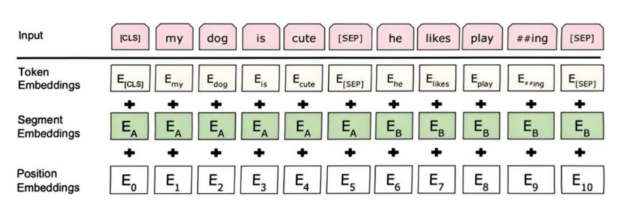

图1-9　Transformer输入表示的三重嵌入结构图

位置编码用于引入序列中词元的相对位置或绝对位置信息，使模型在全并行结构中仍具备序列顺序感。该位置嵌入既可采用固定函数生成，也可通过训练获得，最终三者相加后的向量进入Transformer网络，这是模型理解上下文结构与语序依赖的基础。

此外，近年来还发展出相对位置编码机制，不仅考虑某个词自身的位置，还引入其与目标词之间的相对位置信息，在多头注意力机制中进一步提升了对序列结构的建模能力，显著优化了对长文本、重复结构与嵌套语义的处理效果。

#### 3.上下文建模的技术内涵

上下文建模是指模型在处理某个词语时，能够充分考虑其前后周围词语所携带的信息，从而形成对当前词语在句子中的真实语义理解。上下文信息不仅包括邻近词的语义线索，也包含远距离依赖、主谓关系、句法层级、指代关联等复杂结构

在传统语言模型中，上下文建模受限于窗口大小、记忆深度与信息传递路径，难以准确捕捉长距离依赖。Transformer通过自注意力机制实现任意位置之间的信息直接交互，打破了传统结构对上下文建模的限制，但其能否有效利用上下文，仍然严重依赖于位置编码所提供的顺序信息。

在上下文建模中，位置编码的作用不仅体现在输入层对位置感知的引导，也影响每一层注意力机制的权重分配方式，使模型能够知道当前词应该关注哪些历史或未来词语，这对指代消解、语义一致性判断与任务执行链路构建具有重要意义。

#### 4.长序列与位置编码的扩展机制

随着大模型向更长上下文建模能力的方向发展，传统的位置编码方式在面对上千甚至上万个Token的序列时逐渐显现出表示能力与计算效率的瓶颈问题。为此，研究者提出了多种扩展型位置编码机制，以支持更长文本、更高精度的上下文建模。其中包括：

(1)旋转位置编码(RoPE)：通过在位置编码中引入旋转操作，使得位置信息可以在向量空间中通过角度变换表达，增强了位置表示的连续性与计算稳定性。

(2)可插拔位置编码(ALiBi)：直接在注意力得分中注入位置偏移量，无须额外位置向量，提升模型在推理阶段对未知长度文本的泛化能力。

(3)稀疏注意力与分块位置处理：在处理超长文本时，将序列切分为多个块，引入局部与全局位置编码策略，提升整体计算效率与建模灵活性。

这些机制不断优化位置编码与上下文建模的配合方式，使得大模型具备处理长文档、多轮对话与跨段落推理任务的能力，拓展了智能体系统的应用边界。

#### 5.位置编码在智能体中的应用意义

在语言智能体系统中，位置编码不仅用于基础模型的上下文建模，更是支撑多轮对话状态追踪、复杂任务流程控制与提示词调度等功能的重要技术支点。通过精确标定输入中各段落、命令、变量的位置信息，智能体可以构建任务执行的逻辑结构，从而完成分步任务解析、历史状态检索与工具调用参数绑定等复杂操作。

例如，在多Agent系统中，不同智能体可能处理同一输入序列的不同片段，位置编码机制可用于明确任务段的边界与优先级，避免信息混淆；在工具调用链中，通过明确提示词中参数与说明之间的相对位置关系，提升大模型调用函数的准确性与稳定性。

此外，位置编码还在记忆系统中发挥重要作用，帮助模型识别历史信息在时间轴上的顺序，构建更稳定的任务上下文与对话逻辑，有助于智能体实现跨轮次的连续性决策与行为一致性控制。

## 1.3 大模型能力边界与应用接口

语言模型虽具备强大的语言生成与理解能力，但其在实际应用中仍存在上下文长度限制、推理深度不足、内容控制困难等能力边界。此外，模型的调用能力取决于所提供的API接口设计与输入输出结构约定。本节将围绕模型能力的边界特征、提示词工程的基本策略、输入窗口的管理方式以及多模态能力的接入机制进行系统阐述，帮助厘清模型能力发挥的前提条件与接口控制方式，为智能体系统中模型能力的高效调度提供理论依据。

### 1.3.1 通用能力与推理能力

通用能力与推理能力共同构成了大语言模型的核心智能范式，前者注重语言形式与表达规范，后者强调任务逻辑与认知控制，在智能体系统中分别承担信息输入输出与任务规划执行的核心职能。构建高质量智能体，需要在系统架构中明确两者的能力边界与调度机制，既要保障语言交互的通畅自然，也要推动认知过程的逻辑严密，为复杂任务的顺利执行提供稳定的能力支撑。

#### 1.大语言模型能力的分类

大语言模型具备广泛的通用能力，在语言生成、理解、翻译、摘要等任务中展现出近似人类水平的表现。然而，这些能力并非单一维度可以涵盖，而是在不同认知层次上形成互补关系，通常可从通用语言能力与推理能力两个维度加以划分。前者关注对语言模式的学习与应用，强调语法正确性、语义连贯性与语言表达的自然性；后者则聚焦于在复杂问题中进行逻辑判断、条件分析与多步推导，侧重任务完成过程中的思维链构建与目标导向行为的生成。

智能体系统在构建过程中，既需要语言模型具备处理各种自然语言输入的基础能力，也依赖其推理能力完成多步骤决策、规则匹配与因果判断等高阶任务，因此理解两者之间的区别与交集，是设计Agent行为策略与任务流程的前提条件。

#### 2.语言能力

通用能力是大语言模型最基础也是最广泛的能力范畴，主要来源于大规模文本语料的预训练过程，通过海量句子对模型进行语言模式的学习，使其能够掌握词语搭配、句法结构、语义组织与文本逻辑等语言规律。这种能力在以下几个方面表现尤为显著：

(1)语言理解能力：包括词义辨析、句法结构识别、文本摘要、问答匹配等任务，模型可以通过上下文关系判断词语用法、抽取关键信息或识别语义重心。

(2)语言生成能力：能够在指定的上下文或指令下生成连贯、语法正确的自然语言文本，广泛应用于续写、改写、对话生成与文案创作等。

(3)语言风格与语域控制：通过Prompt引导，模型可以生成符合特定语气、文体或行业术语的文本内容，实现对生成风格的粗粒度调控。

(4)多语言处理能力：具备一定程度的跨语言通用性，可在不同语种之间进行翻译、对齐或语义映射，提升语言智能体的跨文化适应能力。

用语言能力主要反映了模型对语言本身的学习与运用，表现为面向文本特征的模式识别与生成再现，属于大模型的基础服务能力层，是绝大多数智能体对话、交互与表达的支撑根基。

#### 3.推理能力

推理能力是大模型能否胜任复杂任务的关键标志，其本质是在语言表达中实现信息的加工、逻辑的组织与结论的导出。推理不仅要求模型理解输入所包含的显性信息，还要具备隐含关系挖掘、条件判断与多步决策能力，通常包括以下几个方面：

(1)事实推理与常识推理：模型基于训练语料中学习到的世界知识与事实规则，能够判断命题是否合理、两个陈述是否一致，或完成知识补全。

(2)条件推理与假设验证：能够根据如果……那么……结构，模拟条件成立或不成立时的推导路径，是任务规划与流程判断的重要基础。

(3)算术与逻辑推理：涉及对数值、符号或结构化信息的分析与处理，如解决数学题、逻辑谜题或图结构问题。

(4)多步思维链建构：在面对复杂问题时，能够生成中间步骤，逐步推进推理过程，提升生成内容的合理性与可验证性。

推理能力往往不是通过模型单次响应直接体现的，而是依赖于对上下文的长期建模与中间步骤的显式生成，因此需要配合链式提示设计、多轮交互机制或外部记忆支持才能充分发挥。推理能力的强弱决定了模型能否胜任真实世界中的复杂任务，是智能体系统高阶认知行为的实现基础。

#### 4.通用能力

在实际应用中，通用能力与推理能力并非对立存在，而是共同构成语言模型综合智能的两个维度。通用能力是基础，确保输入理解正确、输出表达自然，推理能力是延伸，使模型具备对任务目标的逻辑达成路径构建能力。

例如，在一个问答智能体中，通用能力可帮助识别用户问题并组织回答语言，而推理能力则需要判断问题中的隐含条件、调用外部工具获取信息或构建逻辑链条完成任务。两者的融合使得智能体不仅能看懂和说清，更能想清楚与做正确。


### 1.3.2 输入长度限制与窗口控制

输入长度限制与窗口控制是大模型应用中的关键机制之一，其本质源于Transformer结构在计算复杂度上的约束。通过引入多种策略，如Prompt压缩、Token预算、轮次截断与结构化输入设计，智能体系统可在有限窗口中实现最优的信息利用与行为调度。理解并合理管理上下文窗口，不仅关乎模型性能与输出质量，更直接影响智能体系统的稳定性、健壮性与任务完成效率，是构建工程级语言智能体不可回避的核心议题。

#### 1.大模型上下文窗口的概念基础

在大模型的应用过程中，输入文本需要经过分词器切分为一系列基本处理单元，即Token，模型在处理文本时并非面对原始字符串，而是基于这些Token进行序列建模。然而，大模型在设计上并不能接收无限长度的输入序列，其计算资源受限于显存、结构设计与性能控制，因此必须设置固定的上下文窗口长度，用于约束每次推理所能接受的最大Token数。

所谓上下文窗口，即模型在单次推理过程中所能看到的输入总量，这个窗口不仅包括用户当前输入的文本内容，也包括系统提示词、历史对话内容、函数定义、工具调用描述等上下文信息。一旦输入总Token数超过窗口上限，模型将无法完整处理所有信息，导致内容被截断、信息丢失或响应异常。因此，理解窗口限制的本质机制与控制方式，是智能体系统设计中不可忽视的关键环节。

#### 2.上下文长度限制的形成机制

Transformer架构虽然具备优秀的并行处理能力，但其自注意力机制计算量随序列长度的平方增长，即每个位置都需与所有其他位置进行相似度计算，当Token数量超过数千时，计算与显存压力将急剧上升。为确保模型可在可控成本下运行，绝大多数大语言模型都设定了最大上下文长度的上限。

不同模型根据结构设计与参数规模设定不同的窗口限制。例如，GPT-3支持2048个Token，ChatGPT-4支持8192个Token或更长，而Claude与Qwen系列模型已支持超长上下文能力，部分版本可扩展至32K甚至100K Token。无论何种模型，该限制都决定了每轮模型调用中最多可引入的文本信息总量，对Agent系统中的对话延续、任务分步、工具调用等模块产生直接影响。

此外，部分训练阶段采用固定长度输入截断策略，导致模型即使理论结构支持更长序列，也可能因训练数据分布的差异在处理长输入时性能下降。因此，在系统设计中不仅需要考虑模型结构参数，还应关注训练过程中的长度适应能力。

#### 3.窗口控制策略的核心手段

在面对固定窗口约束时，智能体系统需采用一系列窗口控制策略来管理输入内容，确保关键信息得以保留，同时不超过模型输入上限，主要包括以下几种方法：

(1)Prompt压缩与摘要策略：对历史对话、背景信息进行压缩或摘要，仅保留核心事实、任务目标与关键信息片段。

(2)Token预算分配机制：为系统提示、用户输入、函数描述等各类Token预先设定预算上限，防止某一部分信息占据过多窗口空间。

(3)历史轮次截断机制：在多轮对话中，通过滑动窗口保留最近若干轮对话，较远轮次以摘要或记忆方式存储。

(4)分段式输入结构设计：将输入内容结构化分段，优先级高的信息置于靠前位置，低优先级信息可按需丢弃或压缩。

(5)输入合法性检测与回退机制：在内容注入前预估总Token长度，若超限，则主动触发降级策略或拆分处理流程。

这些策略在LangChain、扣子等智能体框架中已被广泛实现，有效提升了系统的上下文适应能力与模型稳定性。

#### 4.窗口限制对智能体行为的影响

在智能体系统中，窗口限制不仅是技术约束，更直接影响任务规划的策略与模块协作的方式。主要体现在以下几个方面：

(1)对话连贯性受限：多轮交互过程无法完整保留全部历史轮次，可能导致模型遗忘早期上下文，引发响应不一致。

(2)工具调用参数缺失：若函数定义或参数说明被截断，模型可能生成不符合调用规范的输出，影响Agent功能执行。

(3)任务规划链路中断：对复杂任务的分步执行若无法保留足够的中间状态信息，将使模型推理链断裂，难以完成任务闭环。

(4)提示词工程复杂度上升：为适配窗口限制，系统需设计更加紧凑高效的Prompt结构，同时配合动态拼接与摘要机制实现Token优化。

因此，窗口控制不仅是输入预处理问题，更是智能体系统调度与行为稳定性的核心变量之一，这些技术的发展将极大地提升智能体对长文档处理、复杂上下文追踪与长期任务管理的能力，为构建更强大的语言智能系统提供支撑。

### 1.3.3 提示词工程

提示词工程(Prompt Engineering)是指围绕语言模型输入进行设计与优化，使模型产生符合预期的输出。大模型本质上是条件概率预测系统，其生成内容高度依赖于输入文本的结构、语义与上下文提示。因此，通过精心构造输入提示内容，可以有效引导模型在理解、推理、执行等方面表现出更高的准确性与一致性。

提示词工程不仅关乎语句表达，更涉及输入格式、任务定义、约束条件与输出风格控制等多个维度，在智能体系统中尤为关键，它决定了模型在接收任务指令后是否能正确理解意图、调用工具、按步骤执行。

#### 1.提示词的结构化设计

一个高质量的Prompt通常包含以下几个部分：

(1)系统设定(System Prompt)：用于定义模型角色与行为边界。

(2)任务说明(Instruction)：明确当前要执行的任务。

(3)输入内容(Input Content)：提供任务所需的上下文或信息。

(4)输出格式(Output Format)：通过明确模板控制返回内容结构。

以下是一个用于文本摘要的提示词设计示例：

In [3]:
from pathlib import Path
from dotenv import load_dotenv
import os

 # 自动在当前工作目录或父目录寻找 .env
env_path = Path('.') / '.env'
load_dotenv(dotenv_path=env_path)
# 读取密钥
nvidia_api_key = os.getenv('NVIDIA_API_KEY')
if not nvidia_api_key:
    raise RuntimeError("NVIDIA_API_KEY 未在环境变量中找到，请检查 .env 文件或系统环境")

BASE_URL = os.getenv('BASE_URL')
if not BASE_URL:
    raise RuntimeError("BASE_URL 未在环境变量中找到，请检查 .env 文件或系统环境")

MODEL = os.getenv('MODEL')
if not MODEL:
    raise RuntimeError("MODEL 未在环境变量中找到，请检查 .env 文件或系统环境")

In [4]:
from openai import OpenAI # 或兼容库，如 openai-compatibale-qwen

prompt = """
你是一位专业的中文技术文档撰写专家，
请将以下文本进行简洁、准确的摘要，
要求语言通顺，保留技术要点，控制在100字以内：

【原文内容】
{}
"""

document = "Transformer结果是一种基于注意力机制的深度学习架构..."

# 拼接输入内容
final_prompt = prompt.format(document)



# 调用模型生成
response = OpenAI(
    base_url = BASE_URL,
    api_key = nvidia_api_key
).chat.completions.create(
    model=MODEL,
    messages=[{"role":"user","content":final_prompt}],
    temperature=1,
    top_p=1,
    max_tokens=4096,
    stream=False
)

print(response.choices[0].message.content)

Transformer是一种基于自注意力机制的深度学习模型，摒弃卷积和循环结构，采用多头注意力实现并行计算，能够高效捕获序列的全局依赖，已广泛应用于自然语言处理、计算机视觉等领域。


通过LangChain的结构化封装，可对提示词进行模块化管理，并结合上下文、工具调用结果实现动态拼接，这是实现复杂Agent系统的重要工程手段。

提示词工程是大模型应用的控制核心，其质量直接决定智能体行为的准确性、稳定性与响应质量。通过系统设定、任务引导、结构约束与示例驱动等策略，可显著提升大模型输出的可控性与一致性。结合LangChain、Function Calling或低代码平台的提示词管理机制，可进一步提升Agent系统对多任务、多角色与多模态信息的适应能力，这是构建高质量智能体的基础性技术环节。

### 1.3.4 多模态模型

多模态模型(Multimodal Model)作为语言模型的扩展形态，打通了语言、图像、语音等模态之间的信息壁垒，是推动智能体系统具备类人认知能力的关键支撑技术。通过统一表示空间、跨模态语义对齐与生成机制，多模态模型赋予Agent系统更广泛的感知能力与交互能力，未来将在人机交互、机器人控制、文档理解等复杂任务中发挥核心作用，是通向通用智能路径上不可或缺的重要组成部分。

#### 1.多模态模型的提出背景

传统语言模型专注于对纯文本信息的建模与生成，虽然在语义理解与语言生成任务中取得显著成果，但现实世界中的信息往往并非单一模态表达，而是同时包含图像、文本、音频、视频、结构化数据等多种形式。人类智能具备跨模态的信息整合与推理能力，而单一文本模型在处理图文混合、语音指令、视觉问答等任务中存在天然局限。

如图1-10所示，在传统单模态语言模型中，模型仅能处理文本序列，难以理解图像、声音、触觉等丰富的信号，限制了其在真实世界任务中的表现。多模态模型通过引入视觉、语音、三维结构等模态编码器，将非语言信号映射至共享语义空间，使语言模型具备跨模态对齐与联合建模能力。

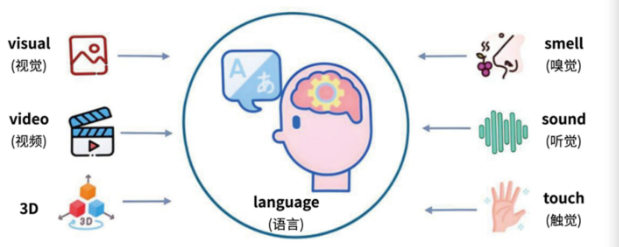

图1-10　多模态模型的感知整合示意图

这些模型结构常采用双塔或融合式架构，结合注意力机制、对比学习或交叉解码器等技术完成语义融合。最终输出统一的语言表示，从而支持图文问答、视频理解、语音指令等复杂交互任务，是实现通用智能的重要技术路径。

为弥合这一差距，多模态模型应运而生，其核心目标是通过构建统一的神经网络架构，实现对不同模态输入的联合建模、语义对齐与跨模态生成，从而构建具有感知−认知−表达能力的通用智能系统。多模态技术已成为大模型能力拓展的重要方向，是智能体系统深入感知现实世界的关键路径。

#### 2.多模态模型的基本构成

多模态模型通常包含3个核心组成部分：模态编码器、跨模态融合模块和模态解码器，分别承担不同类型输入的特征提取、语义整合与目标输出生成任务。

(1)模态编码器：将图像、文本、音频等模态输入转换为统一的表示空间，常用的视觉编码器包括视觉Transformer(ViT)、ResNet等，文本编码器则通常基于语言模型或嵌入模型。

(2)跨模态融合模块：用于整合不同模态之间的信息，建立语义对齐机制，常采用交叉注意力机制、多模态Transformer或对比学习策略实现多模态语义关联。

(3)模态解码器：根据融合后的多模态表示生成目标内容，例如输出文本描述、生成图像内容或执行多模态指令生成响应。

这一结构保证了模型具备同时接收、理解与使用不同模态数据的能力，是图文问答、语音指令控制、视觉推理等任务的基础架构。

#### 3.典型多模态模型结构与代表工作

近年来，多模态模型取得显著进展，涌现出一系列高性能代表模型，主要包括以下几类：

(1)图文对齐模型：例如CLIP通过图文对比学习，将图像与对应描述映射到共享语义空间，具备跨模态检索与相似度判断能力。

(2)图文生成模型：例如BLIP、Flamingo等结构，通过引入图像编码与语言模型结合，实现图像内容生成文本描述或执行指令。

(3)多模态大模型：例如GPT-4V、Qwen-VL、Gemini等，基于大模型架构扩展视觉输入能力，支持图像问答、文档解析、图表分析等复合任务。

(4)多模态对话模型：例如MiniGPT、LLaVA、CoDi等，融合视觉与语言的对话能力，可用于智能助理、机器人感知等任务场景。

以BLIP-2为代表的多模态模型结构如图1-11所示。视觉、音频等模态输入首先通过模态编码器进行特征提取，生成统一维度的向量表示，随后由连接器或可学习查询向量引导的Q-Former模块对这些向量进行压缩与筛选，使其适配大模型的输入结构。在该过程中利用多头注意力机制完成跨模态信息融合。

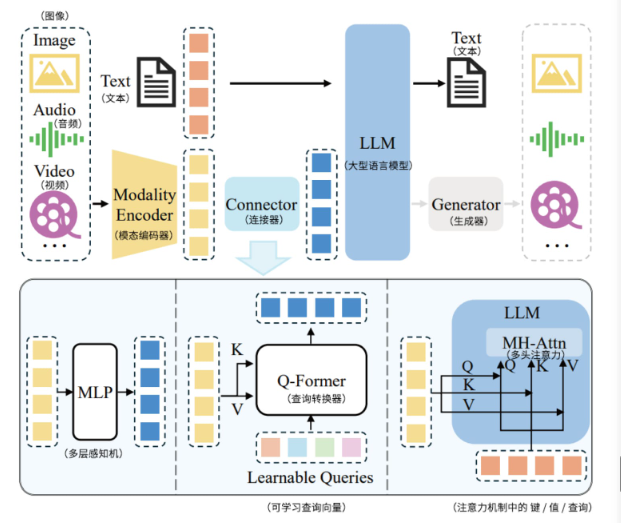

图1-11　典型多模态模型结构与模态融合流程图

多模态特征经转换后注入LLM，参与文本生成或理解任务，支持多模态问答、描述生成与跨模态对齐等能力。该结构通过感知模块解耦+语义注入桥接+语言模型生成的路径，将多模态感知与语言生成能力有效耦合，是当前主流多模态智能体的基础架构之一。

这些模型在构建方法上普遍采用图文双塔结构或多模态Transformer，强调视觉语义理解与语言生成之间的桥接关系，是构建具备通感能力的智能体的关键技术路径。

#### 4.多模态感知在智能体系统中的意义

多模态建模能力为智能体系统提供了从理解文本向理解世界的能力跃升，尤其在复杂任务场景中，多模态感知已成为支撑Agent智能行为的必要条件，主要体现在以下几个方面：

(1)图文问答与知识抽取：可从图像中提取信息并结合文本进行问答推理，适用于图表分析、医学影像解析等任务。

(2)任务引导与环境感知：机器人或虚拟智能体可通过图像理解获取周围环境状态，从而完成路径规划、物体识别与操作决策。

(3)多模态对话交互：支持用户通过语言、图像、语音混合输入控制智能体行为，提升人机交互的自然性与有效性。

(4)模态协同与生成增强：实现文本生成图像、图像生成文本、音频转指令等跨模态表达能力，增强智能体多通道反馈能力。

具备多模态能力的Agent不仅可以处理复杂输入场景，还可通过图文协同理解任务意图，形成更完整的信息闭环。

#### 5.多模态融合的关键技术挑战

尽管多模态模型在表达能力方面具有显著优势，但仍面临诸多技术挑战，包括：

(1)模态对齐困难：图像与文本属于异构数据，维度结构、语义粒度差异大，需要通过对比学习、对齐标注或中间表征统一机制解决。

(2)长文本与高分辨率支持不足：大模型在处理长文本或高分辨率图像时仍受上下文窗口限制，信息可能被截断或压缩丢失。

(3)跨模态推理能力有限：虽然具备基础理解能力，但在复杂图文联动推理、时间序列建模等方面仍有较大提升空间。

(4)高成本与部署难度：多模态模型参数量大、计算消耗高，落地部署需配合边缘推理、模型压缩与硬件优化手段。

因此，在智能体系统设计中，需根据具体任务需求合理选取模态融合策略与模型结构，平衡性能与资源投入。

## 1.4 构建语言智能体的基本流程

语言智能体的构建不仅依赖于大模型的语言生成能力，更关键在于围绕具体任务场景构建合理的输入输出结构、上下文管理机制与工具调用链条，通过引入任务建模、API接口封装、行为规划与反馈调优等关键流程，智能体能够实现从输入理解到任务执行的完整闭环。本节将系统梳理语言智能体的构建流程，明确各模块的协同关系与调用边界，为后续工程实践提供可操作的结构化路径。

### 1.4.1 任务建模与输入输出结构定义

任务建模是构建语言智能体系统的首要环节，其核心目标是将真实世界中的复杂需求转换为语言模型可理解、可执行的结构化任务表示。在大模型驱动的智能体架构中，模型本质上是一个条件生成器，因此必须通过明确的输入输出定义，将任务目标、上下文信息、接口参数等内容组织为符合语言模型理解机制的输入结构，并确保其输出结果具备可解析性与操作性。

有效的任务建模不仅要求对任务逻辑本身有清晰的拆解与分层，还需考虑模型上下文窗口限制、响应控制机制与后处理约定等因素，从而实现智能体行为的准确性、稳定性与可控性。在输入结构方面，常见的形式包括自然语言提示词、JSON封装结构、函数调用声明与多轮对话上下文拼接等，输出结构则通常采用文本摘要、字段抽取、参数结构化或代码生成等方式，部分任务还需引导模型输出标准化结果以供后续系统调用。

构建良好的输入输出结构不仅有助于模型理解意图与生成目标，还为智能体系统中的后续模块（如执行器、工具链、对话管理器等）提供可直接处理的中间数据，是实现语言理解到行为执行闭环的关键起点。

#### 1.任务建模的基本流程

在语言智能体系统中，任务建模的本质是将自然任务转换为大模型可以处理的Prompt输入与可解析输出结构，通常包含以下几个步骤：

##### 01 明确任务类型（如问答、摘要、代码生成、SQL查询等）​。

##### 02 构建自然语言说明或API封装形式的输入提示。

##### 03 设计输出格式（自然语言、JSON、SQL语句等）​。

##### 04 用代码完成结构拼接与模型调用。

#### 2.案例一：生成SQL语句的任务建模

目标：用户描述一个查询目标，由模型生成对应的SQL语句，并返回结构化输出。

In [5]:
from openai import OpenAI #使用OpenAI兼容接口，例如QWen-API

llm = OpenAI(
    base_url = BASE_URL,
    api_key = nvidia_api_key
)

# 构建任务Prompt

user_instruction = "我想查询所有注册时间在2023年之后的用户姓名和邮箱"

prompt = f"""
你是一位数据库专家，请根据以下用户指令生成SQL语句。
要求：
1.表名为users；
2.字段包括name和email；
3.使用标准SQL语法；
4.输出格式为JSON，字段包括sql和explanation。
5.适合中文回答

指令：{user_instruction}
"""

# 调用达模型
response = llm.chat.completions.create(
    model=MODEL,
    messages=[{"role":"user","content":prompt}],
    temperature=0
)

# 输出结果
print(response.choices[0].message.content)

{
  "sql": "SELECT name, email\nFROM users\nWHERE registration_time > '2023-12-31';",
  "explanation": "该语句从 `users` 表中检索所有在 2023 年之后（即注册时间大于 2023‑12‑31）的用户的姓名 (`name`) 和邮箱 (`email`)。使用标准的 SELECT 语法，并在 WHERE 子句中通过比较 `registration_time` 字段实现时间过滤。"
}


此处将自然语言任务描述通过结构化Prompt映射为数据库查询任务，并指定输出为结构化JSON格式，方便后续智能体对SQL语句的执行与解释。

#### 3.案例二：文本抽取任务建模（抽取企业名称与地址）

In [6]:
instruction = "从以下文本中提取公司名称和地址信息，以JSON格式返回。\n\n文本：浙江橙龙科技有限公司位于杭州市余杭区五常街道五常大道100号。"

prompt = f"""
任务说明:从文本中识别提取公司名称与地址信息。

输出格式：
{{
    "company":"...",
    "address":"..."    
}}

请处理如下文本：
{
    instruction
}
"""

response = llm.chat.completions.create(
    model=MODEL,
    messages=[{"role":"user","content":prompt}]
)

# 输出结果
print(response.choices[0].message.content)


{
    "company": "浙江橙龙科技有限公司",
    "address": "杭州市余杭区五常街道五常大道100号"
}


以上示例代码展示了任务建模的基本逻辑：通过结构化Prompt将非结构化的用户意图映射为可计算任务，并通过明确的输出格式设计，使得智能体系统能够基于模型响应完成后续的工具调用、数据库执行或结果反馈。

任务建模作为语言智能体构建的起点，是系统能否稳定运行、正确响应的根本保障，结合LangChain、函数调用(Function Calling)等工具链还可进一步增强其通用性与自动化程度。

### 1.4.2 大模型API设计模式

在构建语言智能体系统的过程中，如何规范、稳定、高效地调用大模型，是系统可用性与工程可维护性的核心问题。大模型本质上作为远程推理服务，通过统一接口接收任务请求并返回响应结果，因此围绕其构建清晰可控的API调用模式，是智能体开发中不可或缺的关键工程步骤。

大模型API设计不仅需满足底层模型调用的基本能力，还应支持多轮上下文管理、函数调用集成、响应解析标准化、错误回退机制等复合行为，是连接模型能力与上层系统功能的中枢枢纽。

目前主流的大模型API接口多基于类OpenAI的ChatCompletion结构，核心调用逻辑是向模型发送一个由多条消息组成的列表，每条消息包含角色、内容与上下文标识。以下是典型的接口模式设计：

In [7]:
from openai import OpenAI

llm = OpenAI(
    base_url = BASE_URL,
    api_key = nvidia_api_key
)

messages = [
    {"role":"system","content":"你是一位金融知识专家，请严格按照要求回答问题。"},
    {"role":"user","content":"请告诉我债权与股票的区别，用表格列出。"}
]

response = llm.chat.completions.create(
    model=MODEL,
    messages=messages,
    temperature=0.3,
    max_tokens=512
)

print(response.choices[0].message.content)

以下是债权（如公司债、国债等）与股票的主要区别，已用表格形式列出，方便直观比较：

| 维度 | 债权（债券） | 股票 |
|------|--------------|------|
| **本质** | 债务凭证，代表借款人对债权人的偿付义务 | 所有权凭证，代表持有人对公司的一部分所有权 |
| **持有人身份** | 债权人（债券持有人） | 股东（股票持有人） |
| **收益来源** | 固定或浮动的利息（票息），到期时偿还本金 | 股利（分红）和资本利得（股价上涨） |
| **收益确定性** | 较高（约定的票面利率），但受发行人信用影响 | 较低，受公司业绩、市场情绪等多因素影响 |
| **风险程度** | 相对较低，优先于股东在清算时受偿；但仍受信用风险、利率风险影响 | 较高，股东在清算时最后受偿，受公司经营风险、市场波动影响 |
| **到期日** | 有固定期限（如5年、10年），到期需偿还本金 | 没有固定期限，除非公司回购或上市退市 |
| **流动性** | 受市场（债券市场）深度影响；部分债券流动性较差 | 通常流动性较好，尤其是大盘股，交易活跃 |
| **投票权** | 无投票权（除特殊可转换债券外） | 有投票权，可参与公司重大决策（如董事会选举） |
| **税收待遇**（以中国为例） | 利息收入需缴纳个人所得税（按“利息、股息、红利所得”计税） | 股利收入需缴纳个人所得


上述调用采用典型的多轮对话结构，通过system设定智能体角色，user提供输入指令，调用返回的输出则构成一轮完整交互过程。模型调用参数如temperature控制生成随机性，max_tokens控制返回上限，是影响智能体行为稳定性与输出长度的重要调控器。

在更复杂的智能体系统中，API设计需进一步考虑以下模式：

(1)工具函数调用(Function Calling)：通过定义函数结构体，让模型根据用户意图选择并调用对应函数，并将参数结构化返回，便于后续由外部系统执行。

(2)流式响应生成(Streaming)：支持逐Token输出，在生成大型内容或实时交互场景下提升响应速度与用户体验。

(3)上下文缓存机制：对多轮对话的历史信息进行状态管理与窗口控制，确保模型理解连续语义，避免超出上下文限制。

(4)异常处理与重试机制：对网络超时、模型崩溃、响应空白等异常情况设定自动回退与多轮重试逻辑，增强系统健壮性。

通过上述API设计模式，可将大模型封装为标准化、组件化、可复用的语言智能服务，为智能体系统的任务调度、行为规划与工具联动提供统一接口，也为LangChain等Agent框架的运行提供技术基础。大模型API设计既是智能体系统连接认知能力与执行能力的桥梁，也是在工程系统中实现语言智能上层协议的关键路径。

### 1.4.3 基于上下文的行为规划设计

语言智能体的本质在于具备针对输入环境作出合理、动态响应的能力，而这一能力的核心依赖于对上下文的理解与调度。大模型本身是一个条件生成系统，其响应不仅依赖于当前输入，更高度依赖于上下文状态的准确构建与表达。因此，在构建复杂智能体时，不能仅依赖静态的Prompt输入，而应通过上下文驱动的行为规划机制，实现任务状态感知、多步意图规划与工具执行路径生成的闭环控制。

所谓基于上下文的行为规划，是指智能体在接收到输入后，不是直接生成结果，而是先综合历史对话、系统状态、已完成子任务与当前目标，构建一个状态丰富的上下文结构，并以此为基础规划下一步行动，包括是否调用外部工具、如何分解子任务、是否中断或回溯流程等操作。

上下文不仅包含语言内容，还应包括变量值、函数调用历史、模型响应状态、用户行为偏好等任务元信息，是智能体感知−认知−执行能力贯通的关键载体。

在实际开发中，可通过以下方式实现上下文驱动的行为设计：

(1)结构化Prompt嵌套：将历史任务状态、中间变量、环境参数封装到Prompt中，引导模型根据这些上下文要素进行行为判断。例如，将已调用函数及其结果作为摘要插入当前Prompt，以支持链式推理。

(2)状态标签与条件提示：在上下文中引入显式标签，如任务阶段：分解中、工具调用结果：成功、用户意图：查询型，帮助模型精准识别任务所处的状态，规划对应行为。

(3)系统动态规划模板：将任务流程拆解为多个状态节点，每个节点定义可行操作与目标状态，引导模型在执行每一步时参考上下文决定是否继续、分支、合并或终止。

(4)多轮上下文拼接策略：通过滑动窗口与摘要融合机制，在有限Token窗口内保留关键信息，使模型能基于长期对话或任务历史作出连续性决策。

以下是一个简单示例，展示如何通过上下文信息引导大模型分阶段完成任务：

In [8]:
prompt = f"""
你是一位智能体助手，当前任务是多步骤问题求解。

任务目标：用户希望了解其信用卡的账单日、还款日，并获取本月账单详情。

已知上下文：
- 用户身份验证完成；
- 已完成步骤：查询账单日，返回每月15日；
- 当前阶段，继续查询还款口

请根据上述上下文，生成用户当前还需了解的信息，并指导下一步行为。

"""

response = llm.chat.completions.create(
    model=MODEL,
    messages=[{"role":"user","content":prompt}]
)

# 输出结果
print(response.choices[0].message.content)

**您当前还需要了解的信息**

1️⃣ **还款日** – 您的信用卡每月的还款截止日期是什么？  
2️⃣ **本月账单详情** – 本月（2026‑07）产生的消费、费用、应还本金及利息等具体信息。

**下一步建议的操作流程**

1. **查询还款日**：我们将调用系统接口获取您卡片的还款日。  
2. **获取本月账单详情**：在确认还款日后，立即为您拉取本月账单的完整明细。

**请确认是否立即执行上述查询**（如无特殊要求，系统可直接进行）：

- 回复 **“确认”** 或 **“继续”**，我们将立刻为您查询还款日并随后提供本月账单详情。  
- 如需其他帮助或想更改查询顺序，请告诉我具体需求。


该示例中，通过嵌入任务阶段、历史行为与用户目标等上下文信息，模型能明确当前所处的状态并合理规划下一步行为，体现出模型具备对行为逻辑的响应能力。

在实际系统中，结合LangChain、MCP协议或状态图管理模块，还可实现更加动态、可配置的上下文行为规划架构，使得智能体具备持续感知、多策略选择与状态追踪能力，是构建高自主性AI Agent的基础机制。

## 1.5 本章小结

本章系统梳理了大模型驱动智能体开发的技术背景与基础架构，明确了智能体的系统定位、结构构成与发展脉络，解析了Transformer为核心的大模型架构及其能力边界，阐明了提示词设计、上下文管理与多模态适配的关键作用，并提出了语言智能体的构建流程，为理解后续章节中的智能体运行机制与系统实现奠定了坚实基础。

# 第2章　智能体系统的组成结构与运行机制

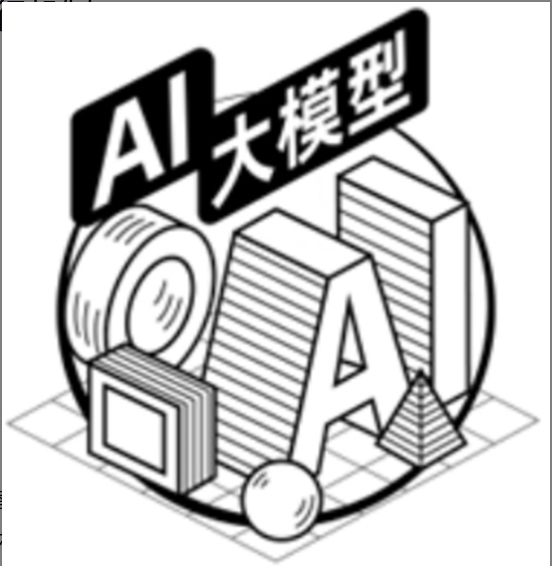

智能体系统作为连接语言大模型与真实任务场景的核心载体，其内部结构设计与运行机制直接决定了系统的智能性、稳定性与扩展性。本章将系统性剖析语言智能体的关键组成模块，涵盖感知、决策、行动与记忆等核心子系统的功能划分与交互关系，进一步引出智能体生命周期管理机制与任务建模方法。在构建实用型智能体时，还需深入理解智能体如何与外部环境进行信息交换、如何追踪对话状态、如何中断恢复并保持上下文连贯性，进而构建具备真实应用能力的智能交互系统。本章内容将为后续的工程构建与框架选型奠定基础。

## 2.1 智能体核心模块构成

构建一个具备通用感知与任务执行能力的智能体系统，必须围绕其核心模块展开严谨的功能划分与结构设计。语言智能体通常由感知、决策、行动与记忆四大模块构成，各模块协同工作，构成从输入理解、意图识别到任务执行与状态维护的完整闭环。

感知模块负责解析输入内容并提取关键信息；决策模块在上下文基础上规划最优行为路径，行动模块则完成实际工具调用或任务响应；记忆模块用于存储对话历史与中间状态，为智能体提供持续性的上下文支持。本节将逐一拆解各模块的职责边界与交互方式，为构建可控、可解释的智能体系统奠定结构基础。

### 2.1.1 感知模块：输入理解与解析

感知模块是智能体架构中最前置的子系统，其主要职责在于接收外部输入，并将非结构化的信息进行语义解析与任务意图识别，为后续的推理与执行模块提供标准化的中间表示。

该模块通常接收用户输入的自然语言指令、图像、结构化数据或其他多模态信号，经过输入预处理、语言理解、槽位抽取、实体识别等一系列流程，将原始输入转换为具备结构语义的任务元信息。

如图2-1所示，感知模块负责接收来自环境的原始输入信号，并将其转换为机器可处理的中间表达形式，常用技术包括语音识别、图像处理、文本解析与多模态融合，通过对输入数据的特征提取与结构化建模，形成面向后续推理环节的高维向量表示。该阶段不仅是信息流入的起点，也是智能体理解外部世界的关键入口。

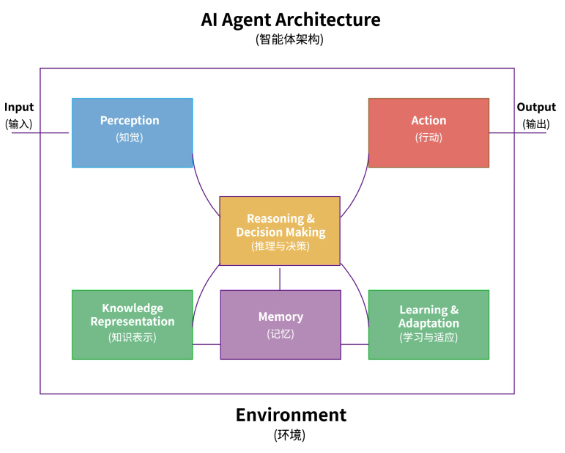

图2-1　智能体架构中的感知模块作用与连接机制

在智能体整体架构中，感知模块与决策模块之间构成直接的数据传导通路，后者依据感知到的信息进行推理与判断，进而触发行动模块完成任务响应。同时，感知结果也被写入记忆系统用于上下文追踪，并与知识表示系统形成联动，为长期任务提供信息支撑与反馈修正基础。

在基于大模型的智能体系统中，感知模块多由提示词(Prompt)解析器与辅助函数组成，通过预设提示词模板引导模型识别输入中的意图类别、实体要素、任务参数与上下文状态，并以JSON、函数调用、标签结构等形式输出解析结果。对于多轮对话任务，感知模块还需结合历史上下文进行状态融合，识别省略意图或指代对象，保持语义连续性。

部分系统会结合规则引擎或轻量级分类模型，对模型输出进行结构补全或多通道容错，提升解析稳定性与准确率。感知模块的解析能力直接决定智能体是否能够正确理解任务需求，是语言驱动任务链条的起点，具有不可替代的结构性价值。

### 2.1.2 决策模块：推理与规划逻辑

决策模块是智能体系统中的核心逻辑单元，主要负责在感知模块完成输入解析之后，基于当前任务状态、上下文信息及历史交互轨迹，进行行为推理与任务规划。该模块的本质是将语言模型的生成能力结构化应用于操作选择、路径规划与条件判断等任务控制环节。其工作过程通常包含意图确认、策略选择、步骤分解与任务链构建等环节。

如图2-2所示，图中智能体依据当前观测状态与外部指令进行推理计算，利用策略函数对复杂环境输入进行状态简化，并在融合记忆与学习信息后选择最优动作。决策模块通过内部策略映射机制将抽象意图转换为具体的动作输出，同时结合历史轨迹动态调整响应策略，以实现智能体行为的可解释性与适应性。

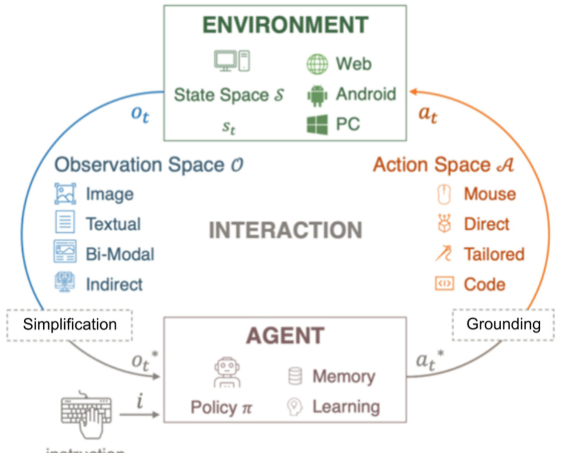

图2-2　智能体决策模块中的推理与行动规划机制

推理模块生成的动作信号涵盖鼠标控制、指令触发、自定义操作与代码执行等多种方式，并通过Grounding机制实现与真实环境的闭环交互。整体决策过程中，强化学习方法用于优化策略迭代过程，使得智能体在复杂环境中具备逐步精细化的行为选择能力。

在语言模型驱动的Agent中，决策逻辑往往由提示词引导模型生成下一步行动建议或应调用的工具函数，并结合外部规则判断系统或预定义模板进行行为约束，确保响应结果可控、可执行。对于多步骤任务，决策模块还需具备任务状态保持与多轮推理能力，能够动态更新目标、识别子任务边界并规划执行顺序。

在部分框架中，决策模块可嵌入ReAct策略，实现推理−行动交替执行；也可结合函数调用协议，将模型推理结果映射为结构化调用指令，驱动执行模块完成实际操作。该模块的规划能力直接影响智能体是否具备问题求解与上下文连贯执行的能力，是语言智能体系统实现认知智能的关键中枢。

### 2.1.3 行动模块：工具执行与响应

行动模块是智能体系统中连接语言生成与现实操作的关键桥梁，其主要职责是将决策模块输出的行动计划映射为可执行的具体操作，并通过调用工具、接口或系统组件完成实际任务执行。该模块不仅是模型能力向系统功能落地的载体，也是语言智能体实现从语义认知向功能交付转换的核心路径。在具备外部世界交互能力的智能体系统中，行动模块往往直接连接数据库、API接口、本地函数、设备驱动或自动化执行脚本，构成具备外部影响力的智能执行闭环。

从结构上看，行动模块通常由工具注册机制、执行调度器、输入参数适配器与结果反馈管理器构成。其中，工具注册机制定义了所有可调用操作的函数签名、功能描述与调用限制，为决策模块提供可选行为列表；执行调度器根据决策输出调度具体函数调用，管理调用时机与并发策略；参数适配器负责将自然语言或结构化任务指令映射为符合工具调用格式的标准参数，确保执行一致性与调用正确性；反馈管理器则收集执行结果，将其封装为模型可理解的格式，供后续对话响应或下一步推理使用，构成行动−感知−反馈循环。

在以大模型为核心的智能体系统中，行动模块的实现依赖于函数调用机制的标准化定义。主流做法包括构建Function Schema，通过JSON Schema等方式明确定义工具函数的输入参数类型、输出结构与调用约束，模型生成结构化调用请求后，由框架完成实际函数绑定与执行。以通义千问Qwen为例，其支持标准化函数调用流程，模型可输出包含函数名与参数字段的调用指令，由系统接收并完成Python函数执行，同时将执行结果插入下一轮上下文作为模型输入，实现推理与执行的闭环融合。

图2-3展示的智能体行动序列基于自然语言指令，自动调用系统级工具完成任务分解与响应执行。行动模块接收到目标表达后，利用预设的工具链注册信息，依次调度日历应用进行时间窗口检索，随后进入邮件模块自动生成并发送会议建议邮件，整个过程由一套基于语义解析与动作映射的控制策略驱动。

在执行过程中，智能体通过对用户意图的结构化理解，确定目标行为所需的系统组件，并保持上下文一致性与信息正确性。行动模块不仅完成跨应用的数据调度与状态追踪，同时对操作时序与资源访问权限进行动态管控，从而实现稳定、高效的工具执行流程。

行动模块还需支持错误处理与执行容错机制。在实际应用中，外部接口可能因参数不合法、服务中断或资源异常导致执行失败，此时行动模块应具备异常捕获、错误回退、替代方案触发等功能，确保智能体系统具备稳健的任务完成能力。常见的策略包括调用失败自动重试、切换备用工具、反馈执行错误供模型重新生成参数等方式，提升系统整体可靠性。

语言智能体在执行图形界面操作时所依赖的工具控制模型如图2-4所示，通过抽象出点击、移动与输入等基本操作，智能体能够在不同粒度下完成从坐标点击到语义级别控件绑定的动作映射。在Grid与Discrete模式中，动作以坐标或控件名称为索引触发，而在Continuous模式下则引入了上下文识别与控件状态管理以确保执行精度。

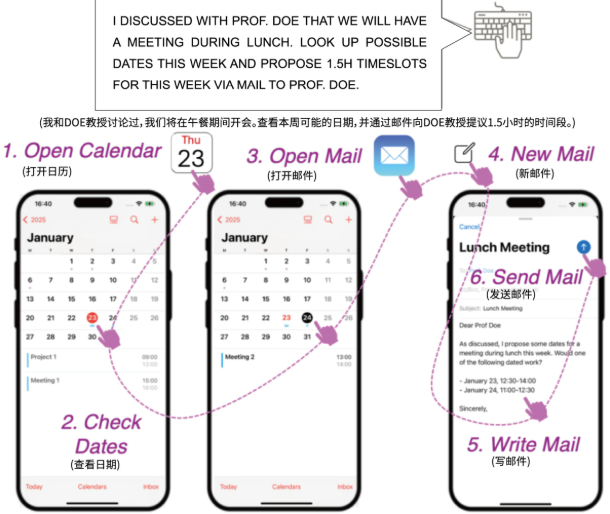

图2-3　智能体行动模块在任务执行中的工具调用流程

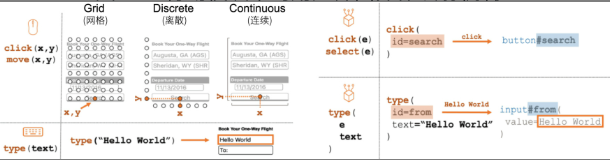

图2-4　行动模块中的用户界面操作映射机制

工具执行的底层依赖于操作语义与界面元素的绑定关系，智能体首先通过界面解析获得控件结构与属性信息，再基于指令生成动作计划，最终以结构化的事件序列执行具体行为，如填充输入框、点击按钮等。该机制显著提升了多模态任务中的自动化能力，是高可靠性行动生成的基础。

在多工具协同的复杂任务中，行动模块还需具备工具链管理能力，通过任务图或执行栈机制，支持多步工具组合调用与中间结果传递。部分系统基于LangChain或自研调度中间件，将工具以节点形式构建成任务链，模型在每步选择调用节点并传递参数，最终形成由语言决策驱动的自动化流程系统。这一结构使智能体具备处理结构化流程任务、接口编排与数据管道处理等高级能力。

综上所述，行动模块不仅是智能体系统的执行层，更是模型能力向系统功能映射的基础设施，其设计优劣直接决定智能体是否具备可控、可扩展与可落地的实际能力。构建通用、稳定、易维护的行动模块是实现大规模部署级智能体系统的关键工程目标。

### 2.1.4 记忆模块：上下文与持久状态

记忆模块是语言智能体系统中支撑多轮交互、任务状态保持与历史经验调用的核心组件，其功能等价于人类大脑中的短期记忆与长期记忆系统，决定了智能体是否具备记得过去和理解当前的能力。

在大模型的调用机制中，由于上下文长度存在物理限制，模型本身并不具备显式持久的记忆能力，因此需要通过外部记忆模块显式管理对话历史、任务变量与关键事件，使智能体能够感知会话连续性、保持交互一致性并基于长期状态动态调节行为。

记忆模块通常分为短期记忆与长期记忆两种类型。短期记忆指的是模型当前可直接读取的提示词上下文信息，包含最近若干轮对话、任务参数、中间调用结果等，通常以内联方式拼接到提示词输入中供模型参考。短期记忆强调即时性、轻量级与高频更新，在多轮对话系统中起到维持语义连续性的作用，如用于识别省略主语、解析指代关系、恢复任务链状态等。而长期记忆则是一种持久化的数据结构，通常存储在外部数据库、文件系统或向量索引中，用于保存重要实体信息、用户偏好、历史决策与领域知识等内容。

在对话过程中，当模型需要调用过往知识或对照历史行为时，可通过向量检索或条件过滤方式动态加载相关长期记忆条目，补充到当前上下文中，增强语言智能体的行为一致性与个性化能力。

如图2-5所示，通过将预训练模型与环境感知模块连接，形成包含长期记忆、行为克隆与强化学习的智能体知识体系，支持记忆模块从静态表示过渡到动态适应。在此基础上，智能体可通过行为反馈不断修正知识表达，增强决策稳定性与上下文一致性。

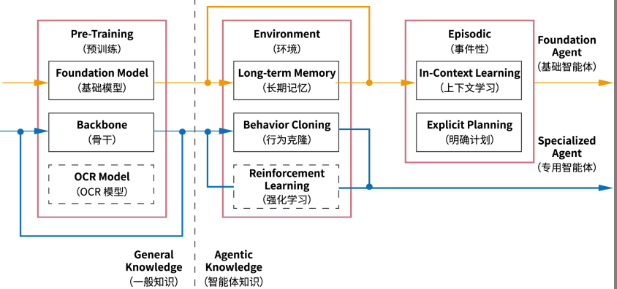

图2-5　融合通用知识与智能体知识的智能体记忆结构演化机制

在记忆机制中，长期记忆负责存储跨任务状态、历史操作与环境映射，支撑持续性任务执行；短期记忆则依托上下文学习与显式规划，支撑复杂任务中的推理与溯源。通过分层管理记忆信息，智能体得以维持语境连续性与交互一致性，为Foundation Agent与Specialized Agent提供关键支撑。

在实际系统中，记忆模块的技术实现涉及多个关键机制。首先是记忆存储结构的设计，短期记忆常以缓存形式存在本地变量或临时数据库中，长期记忆则可采用文档数据库（如MongoDB）​、关系数据库（如PostgreSQL）或向量数据库（如FAISS、Chroma）进行组织与检索。其次是记忆更新策略，系统需根据会话进展动态决定何时将短期内容转入长期存储，或在内存满载时进行剪裁与摘要。常见的策略包括基于回合数滚动更新、基于权重与评分机制选择保留内容、基于内容相似度进行合并去重等方式，确保记忆内容保持高相关性与高效率。

记忆读取机制同样至关重要。对于长期记忆的调取，智能体通常通过Embedding（嵌入）模型将当前对话内容编码为向量表示，再在向量数据库中查找相似内容并作为参考材料追加到提示词中。在结构化记忆中，系统还可通过字段匹配、标签检索或函数筛选方式实现精准提取。为了提升系统效率，部分框架会预先建立知识缓存池，对高频访问的记忆项进行热缓存处理，减少冗余调用。

在具备工具调用能力的智能体系统中，记忆模块还能与任务状态管理深度融合，记录任务的阶段性进度、工具调用结果与用户中断位置，实现任务恢复、分段执行与流程回溯等复杂行为管理。此外，通过记忆模块实现个性化内容定制也是当前智能体发展的关键方向之一，系统可记录不同用户的行为模式、内容偏好与接口习惯，自动调整交互风格与策略，提高响应贴合度与用户满意度。

总的来说，记忆模块作为语言智能体的状态管理与语义延续核心组件，承载了上下文信息持久化、历史任务状态存储、长期知识积累与行为一致性保障等多重职能，是实现类人认知、个性化响应与任务链闭环执行的基础机制。合理设计、灵活扩展与高效调度记忆模块，是构建实用型、高性能智能体系统的必要条件。

## 2.2 智能体生命周期管理

智能体并非静态组件，而是具备运行态变化与状态管理能力的动态系统，其生命周期管理机制直接决定了任务执行的连续性、对话状态的完整性以及资源使用的有效性。从智能体的创建、初始化到运行期间的上下文演化、状态追踪，再到会话中断、恢复与最终注销，生命周期各阶段均需配套的状态管理策略与系统保障措施。尤其在长时间多轮对话、跨任务切换或系统异常场景下，稳定且精细化的生命周期控制是实现工程级智能体应用的核心。本节将围绕Agent的运行状态流转过程，剖析关键控制点与实现方法。

### 2.2.1 启动与初始化过程

智能体的生命周期从启动阶段正式开始，启动过程的主要目标是完成系统配置加载、核心组件初始化、环境连接建立以及初始状态注册等准备性工作。一个结构良好的智能体启动流程应具备高度的模块化、可追踪性与容错能力，确保整个系统在运行前处于稳定与可控的状态。

在Qwen智能体的架构中，智能体对象的初始化通常包括4个关键环节：

(1)加载模型配置，包括模型名称、温度、最大Token长度等推理相关参数。

(2)注册工具函数并声明其功能及参数结构，供后续模型调用。

(3)加载默认记忆(Memory)或上下文(Context)，以支持上下文拼接与长期记忆初始化。

(4)定义智能体的元信息，包括名称、角色设定与行为边界。

为了提升可维护性，智能体的启动过程应支持配置项参数化、日志追踪与启动失败回退机制。此外，为应对真实应用中的多环境部署需求，智能体的初始化流程还需具备对接数据库、API服务或存储系统的能力，从而实现多源资源的同步与跨模块的协调启动。

如图2-6所示，智能体系统的生命周期从启动(Start)阶段开始，系统会触发主控逻辑并建立初始运行环境，随后进入加载配置(Load Configuration)阶段，读取系统参数、模型路径、工具列表、数据库连接信息等关键配置文件，以保证运行环境与业务逻辑的一致性。该阶段通常支持动态热加载机制，使系统能够在不中断主进程的情况下，调整智能体的角色设定与行为策略。

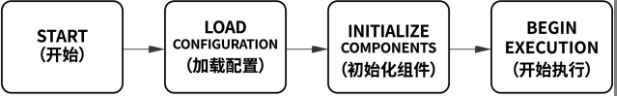

图2-6　智能体启动与初始化流程图

在组件初始化(Initialize Components)阶段，系统会逐一完成大模型、记忆模块、工具函数、插件接口与安全策略的加载与注册，确保各模块在进入执行阶段前状态一致、依赖完整。最后在执行入口(Begin Execution)阶段，智能体正式进入监听状态或对话响应状态，开始响应外部用户输入或系统任务调度，实现智能体从配置到执行的完整闭环。

以下代码演示了一个具备Qwen函数调用(Function Call)功能的智能体如何完成启动流程。

【例2-1】实现一个基于Qwen智能体框架的智能体启动过程，涵盖模型加载、工具注册、系统提示词配置、初始化记忆(Memory)注入及多轮日志追踪，并通过函数调用能力实现工具调度。

In [18]:
# agent_startup.py

import datetime
from typing import List
from qwen_agent.agents import Assistant
from qwen_agent.tools.base import BaseTool,register_tool,TOOL_REGISTRY
from qwen_agent.utils.output_beautify import typewriter_print




# 初始化工具：当前时间工具
if 'GetTimeTool' in TOOL_REGISTRY:
    del TOOL_REGISTRY['GetTimeTool']

@register_tool('GetTimeTool')
class GetTimeTool(BaseTool):
    description = "获取当前系统时间"
    parameters = [{
            'type': 'string',
            'description': 'Detailed description of the desired image content, in English',
        }]
    def call(self,params:str,**kwarg)->str:
        now = datetime.datetime.now()
        return now.strftime("当前时间是：%Y年%m月%d日 %H:%M:%S")
    
# 初始化工具：任务初始化检查工具
if 'StartupCheckTool' in TOOL_REGISTRY:
    del TOOL_REGISTRY['StartupCheckTool']

@register_tool('StartupCheckTool')
class StartupCheckTool(BaseTool):
    description = "执行智能体启动时的系统检查任务"
    parameters = [{"type":"string","properties":{}}] 
    def call(self,params:str,**kwarg)->str:
        checks = [
            "模型加载完成",
            "工具已注册",
            "记忆注入成功",
            "上下文初始化完成"
        ]
        return "系统初始化检查通过："+",".join(checks)

In [19]:
# agent_startup.py

import logging
import datetime
from typing import List
from qwen_agent.agents import Assistant
from qwen_agent.tools.base import BaseTool,register_tool,TOOL_REGISTRY
from qwen_agent.utils.output_beautify import typewriter_print


logging.basicConfig(
    filename='agent_startup.log',
    level=logging.INFO,
    format='%(asctime)s-%(levelname)s-%(message)s'
)

# 构建Agent对象
def build_agent()->Assistant:
    logging.info("启动Agent构建流程")

    llm = {
        'model': MODEL,
        'model_server': BASE_URL, 
        'api_key': nvidia_api_key,
        # 'generate_cfg': {
        #     #'temperatrue': 0.3,
        #     #'max_token':512
        # }
    }

    tools = ['GetTimeTool','StartupCheckTool']
    agent = Assistant(
        name="SystemStartupAgent",
        llm=llm,
        function_list=tools,
        system_message="你是一位系统智能体助手，负责初始化流程、工具检查与运行日志监控。"
    )
    logging.info("智能体构建完成")
    return agent

# 启动测试交互
def run_startup_sequence():
    agent = build_agent()
    logging.info("执行工具调用测试")
    messages = []
    messages.append({'role': 'user', 'content': '请执行一次系统检查'})
    res1 = list(agent.run(messages=messages))[-1]
    print(">> 系统检查响应: ",list(res1)[-1].get("content",""))
    logging.info("执行时间工具测试")
    messages.clear()
    messages.append({'role': 'user', 'content': '请告诉我现在几点'})
    res2 = list(agent.run(messages=messages))[-1]
    print(">> 当前时间响应：",list(res2)[-1].get("content",""))

    logging.info("智能体初始化流程全部完成")

if __name__=="__main__":
    run_startup_sequence()

2026-07-18 12:21:37,434 - base.py - 780 - INFO - ALL tokens: 5, Available tokens: 57981
2026-07-18 12:21:39,692 - base.py - 780 - INFO - ALL tokens: 42, Available tokens: 57981
2026-07-18 12:21:40,925 - base.py - 780 - INFO - ALL tokens: 4, Available tokens: 57981


>> 系统检查响应:  系统检查已完成，确认所有组件均正常运行。可以继续进行后续操作或提问。如需查看当前时间，请告知。


2026-07-18 12:21:44,010 - base.py - 780 - INFO - ALL tokens: 41, Available tokens: 57981


>> 当前时间响应： 现在的时间是 2026年07月18日 12:21:44。祝您有美好的一天！


智能体的启动与初始化是其生命周期中的第一阶段，其复杂性远高于普通脚本执行，必须完成模型配置、工具注册、系统提示词注入与运行环境同步等多重任务。通过本小节示例代码可见，利用Qwen智能体框架可实现模块化启动流程，并通过函数调用(Function Call)功能实现对执行环境的自检与时间调度等初始功能验证。在工程实践中，还可进一步引入配置中心、权限认证、模型热更新与工具动态注册机制，扩展启动流程的通用性与可维护性，是构建多智能体协同平台的重要基础模块。

### 2.2.2 对话状态追踪机制

对话状态追踪是智能体保持上下文一致性与语义连续性的核心机制，尤其在多轮任务型交互中，智能体必须能够准确识别对话所处阶段、存储中间变量、跟踪任务进度并根据用户输入动态调整行为路径。

传统语言模型由于缺乏显式状态表示能力，通常通过提示词拼接实现弱状态管理，而在智能体系统中，则需设计结构化的状态容器与流程控制逻辑，对每一轮交互进行状态更新与历史存储，以支持子任务分解、条件跳转、用户修正处理与中断恢复等复杂交互过程。

如图2-7所示，对话状态追踪(Dialogue State Tracking)通过将输入语音经由语音识别模块(Automatic Speech Recognition，ASR)与自然语言处理模块(Natural Language Processing，NLP)处理后，提取用户意图与对话行为，并由上下文编码器(Context Encoder)对多轮语义表示进行聚合，生成对话表示向量作为后续槽位识别与状态推理的基础。该表示融合当前输入与历史上下文信息，增强模型对多轮目标状态的稳定性判断能力。

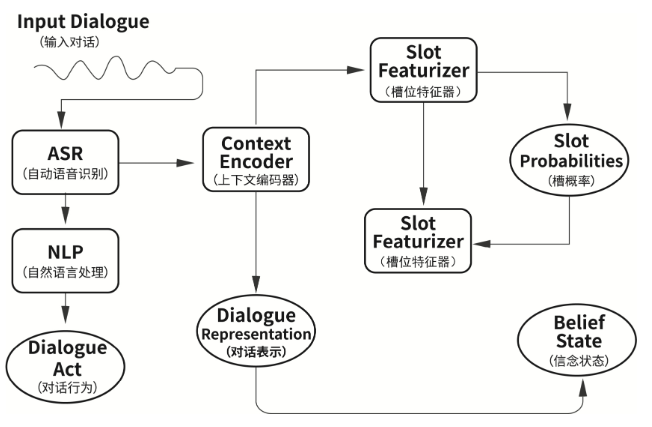

图2-7　面向任务型智能体的对话状态追踪机制流程图

对话表示随后输入至槽位特征器(Slot Featurizer)，该模块对每个领域的候选槽位生成特征向量，并预测其可能取值的概率分布，最终更新信念状态(Belief State)，即智能体对当前任务环境下用户需求的内部建模结果。该信念状态将作为后续意图推理、策略规划与响应生成的基础，确保系统持续理解上下文并作出连贯回应。



In [35]:
# agent_state_tracking.py

import json5
from qwen_agent.agents.memo_assistant import MemoAssistant
from qwen_agent.tools.base import BaseTool,register_tool,TOOL_REGISTRY

# 工具一：记录会议主题
if 'SetTopicTool' in TOOL_REGISTRY:
    del TOOL_REGISTRY['SetTopicTool']

@register_tool('SetTopicTool')
class SetTopicTool(BaseTool):
    description="设置会议主题"
    parameters = {
        "type":"object",
        "properties":{
            "topic":{
                "typing":"string",
                "description":"会议主题"
            }
        },
        "required":["topic"]
    }
    
    def call(self,params:dict,**kwargs)->str:
        topic = json5.loads(params)['topic']
        return f"会议主题已设置为：{topic}"


# 工具二：记录会议时间
if 'SetTimeTool' in TOOL_REGISTRY:
    del TOOL_REGISTRY['SetTimeTool']

@register_tool('SetTimeTool')
class SetTimeTool(BaseTool):
    description="设置会议时间"
    parameters = {
        "type":"object",
        "properties":{
            "time":{
                "typing":"string",
                "description":"会议时间" 
            } 
        },
        "required":["time"]
    }
    
    def call(self,params:dict,**kwargs)->str:
        time = json5.loads(params)['time']
        return f"会议时间已设置为：{time}"


# 工具三：设置与会人
if 'SetAttendeesTool' in TOOL_REGISTRY:
    del TOOL_REGISTRY['SetAttendeesTool']

@register_tool('SetAttendeesTool')
class SetAttendeesTool(BaseTool):
    description="设置与会人"
    parameters = {
        "type":"object",
        "properties":{
            "attendees":{
                "typing":"string",
                "description":"人员名单"
            }
        },
        "required":["attendees"]
    }
    
    def call(self,params:dict,**kwargs)->str:
        attendees = json5.loads(params)['attendees']
        return f"与会人员已设置为：{attendees}"


# 构建智能体
def build_state_agent()->MemoAssistant:
    llm = {
        'model': MODEL,
        'model_server': BASE_URL, 
        'api_key': nvidia_api_key,
        # 'generate_cfg': {
        #     #'temperatrue': 0.3,
        #     #'max_token':512
        # }
    }
    tools = ['SetTopicTool','SetTimeTool','SetAttendeesTool']
    agent = MemoAssistant(
        name="SystemStartupAgent",
        llm=llm,
        function_list=tools,
        system_message="你是一个会议助手智能体,请协助用户完成会议主题、时间、与会人员设定,需记录所有输入信息以备后续回顾"
    )
    return agent


# 运行模拟对话过程
def run_tracking_test():
    agent = build_state_agent()
    messages = []
    messages.clear()
    messages.append({'role': 'user', 'content': '我要安排一场关于AI发展的会议'})
    res1 = list(agent.run(messages=messages))[-1]
    print(list(res1)[-1].get("content",""))
    messages.clear()
    messages.append({'role': 'user', 'content': '会议时间定在5月3日上午10点'})
    res1 = list(agent.run(messages=messages))[-1]
    print(list(res1)[-1].get("content",""))
    messages.clear()
    messages.append({'role': 'user', 'content': '参加人包括：张三、李四和王五'})
    res1 = list(agent.run(messages=messages))[-1]
    print(list(res1)[-1].get("content",""))
    messages.clear()
    messages.append({'role': 'user', 'content': '请总结一下日前的会议信息'})
    res1 = list(agent.run(messages=messages))[-1]
    print(list(res1)[-1].get("content",""))
    
if __name__ == "__main__":
    run_tracking_test()

2026-07-18 12:57:30,864 - base.py - 780 - INFO - ALL tokens: 7, Available tokens: 57821
2026-07-18 12:57:32,202 - base.py - 780 - INFO - ALL tokens: 34, Available tokens: 57821
2026-07-18 12:57:34,392 - base.py - 780 - INFO - ALL tokens: 11, Available tokens: 57821


好的，会议的主题已经确认。  
接下来请告诉我：

1. **会议时间**（例如：2026年8月15日 上午10点）  
2. **与会人员**（请列出姓名或部门，如：张三、李四、技术部等）  

我会把所有信息记录下来，以便后续回顾。


2026-07-18 12:57:37,717 - base.py - 780 - INFO - ALL tokens: 48, Available tokens: 57821
2026-07-18 12:57:40,088 - base.py - 780 - INFO - ALL tokens: 12, Available tokens: 57821


好的，会议时间已经记录为 **5月3日上午10点**。  
接下来，请告诉我：

1. **会议主题**（比如：项目进度汇报、产品发布策划等）  
2. **与会人员名单**（请提供姓名或部门，多个请用逗号分隔）

我会把这些信息一起保存，方便后续回顾。


2026-07-18 12:57:41,536 - base.py - 780 - INFO - ALL tokens: 7, Available tokens: 57821


{"name": "SetAttendeesTool", "arguments": {"attendees": "张三、李四和王五"}}


2026-07-18 12:57:43,261 - base.py - 780 - INFO - ALL tokens: 72, Available tokens: 57821


以下是最近一次会议的关键信息概览：

- **会议主题**：关于AI发展的会议  
- **会议时间**：2026-05-03 10:00  
- **与会人员**：张三、李四、王五  

如需修改或补充上述信息，请随时告诉我！
